# **`Mục 1 — CHUẨN BỊ CHO HỌC MÁY`**

**Mục tiêu**:
- Load dữ liệu đã tiền xử lý
- Kiểm tra nhanh dữ liệu đầu vào cho Học máy
---

# `1.1. Load dữ liệu đã tiền xử lý`

Ta sẽ load toàn bộ dữ liệu đã được xử lý và lưu trong thư mục `data/processed/`.

Cụ thể:
- `X_train.npy`, `X_val.npy`, `X_test.npy`: các ma trận đặc trưng sau khi đã được tiền xử lý.
- `y_train.csv`, `y_val.csv`, `y_test.csv`: nhãn giá nhà tương ứng.
- `feature_info.json`: file chứa danh sách tên các feature sau xử lý.
- `preprocessor.pkl`: pipeline xử lý dữ liệu đã lưu từ bước preprocessing (nếu cần sử dụng lại).

Việc load dữ liệu đúng và đầy đủ là bước đầu tiên đảm bảo quy trình học máy hoạt động chính xác.

---

#### import thư viện

In [1]:
import numpy as np
import pandas as pd
import json
import joblib
from pathlib import Path

#### Định nghĩa đường dẫn tới thư mục data đã xử lý

In [2]:
import os
project_dir = r"d:\Python\MachineLearning\house-price-predict"

os.chdir(project_dir)

print("Đường dẫn hiện tại:", os.getcwd())
print("Các file trong data/processed:", os.listdir("data/processed"))

Đường dẫn hiện tại: d:\Python\MachineLearning\house-price-predict
Các file trong data/processed: ['engineered_dataset.csv', 'feature_info.json', 'X_preprocessed.npy', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'y.csv', 'y_test.csv', 'y_train.csv', 'y_val.csv']


In [3]:
DATA_DIR = Path("data/processed")

#### Load feature names

In [4]:
with open(DATA_DIR / "feature_info.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)
    feature_names = feature_info

#### Load X data

In [5]:
X_train = np.load(DATA_DIR / "X_train.npy")
X_val   = np.load(DATA_DIR / "X_val.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")

#### Load y data

In [6]:
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["price"].values
y_val   = pd.read_csv(DATA_DIR / "y_val.csv")["price"].values
y_test  = pd.read_csv(DATA_DIR / "y_test.csv")["price"].values

#### Load preprocessor

In [10]:
preprocessor_path = Path("models/preprocessor.pkl")
preprocessor = None
if preprocessor_path.exists():
    preprocessor = joblib.load(preprocessor_path)
    print("Loaded preprocessor.pkl")

print("Dữ liệu đã được load thành công!")

Loaded preprocessor.pkl
Dữ liệu đã được load thành công!


# `1.2. Kiểm tra nhanh dữ liệu đầu vào cho học máy`

Mục tiêu:
1. Kiểm tra kích thước của các tập dữ liệu:
   - `X_train`, `X_val`, `X_test`
   - `y_train`, `y_val`, `y_test`
2. Đảm bảo số mẫu giữa X và y khớp nhau.
3. Kiểm tra xem có NaN còn sót lại không.
4. Kiểm tra phân phối biến mục tiêu `Price` để hiểu rõ dữ liệu đầu vào.

Việc kiểm tra này giúp ta xác minh:
- Không có lỗi khi load dữ liệu.
- Không có lỗi tiền xử lý.
- Dữ liệu sẵn sàng đưa vào mô hình học máy.

---


#### Kiểm tra kích thước

In [11]:
print("* Kích thước X/y:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test:", y_test.shape)

* Kích thước X/y:
X_train: (21156, 398)
y_train: (21156,)
X_val:   (4533, 398)
y_val:   (4533,)
X_test:  (4534, 398)
y_test: (4534,)


#### Kiểm tra NaN

In [12]:
print("\n* Kiểm tra NaN:")
print("NaN trong X_train:", np.isnan(X_train).sum())
print("NaN trong y_train:", np.isnan(y_train).sum())


* Kiểm tra NaN:
NaN trong X_train: 0
NaN trong y_train: 0


---
## `Nhận xét`:
### ✔️ Dữ liệu đã được load đầy đủ và chính xác

Các file dữ liệu `.npy` và `.csv` đã được tải thành công, với kích thước như sau:

- **Train set:**  
  - X_train: (21156, 398)  
  - y_train: (21156,)

- **Validation set:**  
  - X_val: (4533, 398)  
  - y_val: (4533,)

- **Test set:**  
  - X_test: (4534, 398)  
  - y_test: (4534,)

Điều này cho thấy:
- Dữ liệu đã được chia theo đúng tỷ lệ.  
- Không có sự lệch hoặc mất mẫu giữa X và y.  
- Số lượng feature sau tiền xử lý là **398**, khá lớn, cho thấy data đã trải qua nhiều bước mã hóa & biến đổi đặc trưng.

---

### ✔️ Không còn giá trị thiếu (NaN)

Kết quả kiểm tra NaN:

- NaN trong X_train: **0**  
- NaN trong y_train: **0**

Điều này khẳng định quá trình tiền xử lý đã xử lý sạch missing values và dữ liệu hoàn toàn sẵn sàng cho bước huấn luyện mô hình.

---

# `1.2.1. Kiểm tra phân phối biến Price (y_train)`

Phân phối dữ liệu giá nhà rất quan trọng để:
- Biết dữ liệu có bị lệch (skewed) hay không.
- Xác định các mô hình phù hợp (Linear Regression thường nhạy với skewness).
- Hỗ trợ đánh giá baseline và chất lượng mô hình.


#### Thống kê phân phối y_train

In [13]:
print("Min:", y_train.min())
print("Max:", y_train.max())
print("Mean:", y_train.mean())
print("Median:", np.median(y_train))
print("25%:", np.percentile(y_train, 25))
print("75%:", np.percentile(y_train, 75))

Min: 1.0
Max: 11.5
Mean: 5.873305917942901
Median: 5.9
25%: 4.2
75%: 7.55


#### Ta vẽ biểu đồ Histogram cho `y_train`.

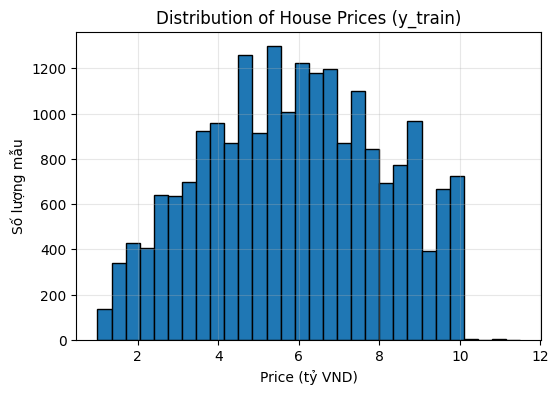

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y_train, bins=30, edgecolor='black')
plt.title("Distribution of House Prices (y_train)")
plt.xlabel("Price (tỷ VND)")
plt.ylabel("Số lượng mẫu")
plt.grid(alpha=0.3)
plt.show()


---
### **`Nhận xét` quan trọng:**
- Biểu đồ histogram cho thấy phân phối giá nhà khá **đều và tự nhiên**, trải dài từ 1 → 11.5 tỷ.
- Dữ liệu không bị lệch nghiêm trọng (skewed) như những tập giá nhà thông thường.
- Mean ≈ Median → phân phối khá cân bằng.
- Khoảng giá tập trung chủ yếu trong vùng **4–8 tỷ**, tương ứng với phân vị 25–75%.

### **Ý nghĩa đối với mô hình:**
- Linear Regression có khả năng hoạt động tốt vì phân phối không quá lệch.
- Các thuật toán dựa trên khoảng cách như KNN cũng phù hợp vì dữ liệu khá phân tán đều.
- Không có outlier quá lớn → giảm nguy cơ mô hình bị nhiễu.
---

# `1.3. Định nghĩa bài toán & lựa chọn metric`

Trong dự án này, ta thực hiện **hai bài toán học máy**:

## `1.3.1. Bài toán Hồi quy (Regression)`
**Mục tiêu:** Dự đoán giá nhà (`Price`), là biến liên tục.

### `Các metric sử dụng`:
- **MSE (Mean Squared Error)**  
  Phạt sai số lớn rất mạnh.
- **RMSE (Root MSE)**  
  Đơn vị giống với giá trị thực → dễ giải thích.
- **MAE (Mean Absolute Error)**  
  Trung bình khoảng sai số tuyệt đối.
- **R² Score**  
  Đo mức độ mô hình giải thích được phương sai dữ liệu.

---

## `1.3.2. Bài toán Phân lớp (Classification)`
**Mục tiêu:** Dự đoán nhóm giá nhà:
- **Low**
- **Medium**
- **High**

Các nhóm sẽ được tạo từ giá `Price`.

### `Các metric sử dụng`:
- **Accuracy** – Tỷ lệ dự đoán đúng.
- **Precision** – Mức độ chính xác của dự đoán.
- **Recall** – Mức độ bắt được các mẫu đúng.
- **F1-score** – Trung hoà Precision và Recall.
- **Confusion Matrix** – Ma trận so sánh dự đoán vs thực tế.

---


### `Nhận xét`: 
#### Dựa trên mục tiêu dự án, ta triển khai song song **hai bài toán học máy**:

### **(1) Hồi quy – Dự đoán giá nhà (Price)**
- Biến mục tiêu liên tục.
- Metric lựa chọn:
  - **MAE**
  - **MSE**
  - **RMSE**
  - **R²**

→ Đây là bộ metric tiêu chuẩn cho bài toán regression, đảm bảo đánh giá mô hình đa chiều.

### **(2) Phân lớp – Dự đoán nhóm giá (Low/Medium/High)**
- Giá nhà được chia nhóm dựa trên khoảng giá.
- Metric lựa chọn:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score (macro)**
  - **Confusion Matrix**

→ Bộ metric phù hợp cho bài toán multi-class classification và cho phép đánh giá từng lớp một cách cân bằng.

---
---
- .
- .
- .
---
---
- .
- .
- .
---
---

# **`Mục 2 — Regression – Dự đoán giá nhà (Price)`**

---

## `2.1. Baseline Model — Dự đoán Giá trị Trung bình (Regression)`

**`Mô hình Baseline`** là mô hình đơn giản nhất, được sử dụng để thiết lập một **mốc so sánh** (**`benchmark`**) tối thiểu cho tất cả các mô hình phức tạp hơn.

### Ý tưởng Cốt lõi
* **Chiến lược:** Mọi mẫu trong tập dữ liệu kiểm tra (**validation/test set**) sẽ được dự đoán bằng **giá trị trung bình** của toàn bộ tập dữ liệu huấn luyện ($y_{\text{train}}$).
* **Bản chất:** Đây là mô hình **không học** bất kỳ mối quan hệ nào giữa các thuộc tính (**feature**) và biến mục tiêu (**target**).
* **Nguyên tắc:** Nếu mô hình Học máy phức tạp của chúng ta **không đạt hiệu suất tốt hơn** mô hình Baseline, điều đó chứng tỏ mô hình ML **chưa có ý nghĩa** hoặc đang bị **underfitting**.

### Công thức Dự đoán
Giá trị dự đoán ($\hat{y}$) cho bất kỳ mẫu nào được tính bằng giá trị trung bình của tập huấn luyện:

$$
\hat{y} = \text{mean}(y_{\text{train}})
$$

### Metric Đánh giá
Các chỉ số thường được sử dụng để đánh giá hiệu suất của mô hình Baseline (và các mô hình Hồi quy khác):

* **`MAE`** (Mean Absolute Error)
* **`MSE`** (Mean Squared Error)
* **`RMSE`** (Root Mean Squared Error)
* **$R^2$ score** (Hệ số xác định)

### Tầm quan trọng
Việc đánh giá Baseline Model giúp chúng ta hiểu rõ mô hình đơn giản nhất hoạt động tốt đến mức nào, thiết lập một **chuẩn cơ sở** để so sánh và đánh giá tất cả các mô hình Hồi quy được xây dựng sau đó.

---

#### Import thư viện

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### Tính giá trị dự đoán baseline

In [16]:
baseline_value = y_train.mean()
baseline_pred = np.full_like(y_val, baseline_value)

#### Tính các metric

In [17]:
mse_baseline  = mean_squared_error(y_val, baseline_pred)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline  = mean_absolute_error(y_val, baseline_pred)
r2_baseline   = r2_score(y_val, baseline_pred)

print("🔹 Baseline Model Evaluation (predict = mean(price))")
print(f"Mean Price (y_train): {baseline_value:.4f}")
print("-" * 40)
print(f"MAE  : {mae_baseline:.4f}")
print(f"MSE  : {mse_baseline:.4f}")
print(f"RMSE : {rmse_baseline:.4f}")
print(f"R²   : {r2_baseline:.4f}")

🔹 Baseline Model Evaluation (predict = mean(price))
Mean Price (y_train): 5.8733
----------------------------------------
MAE  : 1.8097
MSE  : 4.7568
RMSE : 2.1810
R²   : -0.0008


---

## `Nhận xét` Kết quả Đánh giá Baseline Model (Hồi quy)

**Baseline Model** sử dụng giá trị trung bình của tập huấn luyện ($y_{\text{train}}$) để dự đoán cho tất cả các mẫu trong tập kiểm tra/đánh giá (**validation set**).

### Giá trị Dự đoán Cố định
Giá trị trung bình được tính là:
$$
\text{Mean}(y_{\text{train}}) = \mathbf{5.8733} \quad (\text{tỷ VND})
$$

### Kết quả Đánh giá trên Tập Validation

| Metric | Giá trị |
| :---: | :---: |
| **MAE** | $1.8097$ |
| **MSE** | $4.7568$ |
| **RMSE** | $2.1810$ |
| **$R^2$ score** | $-0.0008$ |

---

## Diễn giải Chi tiết Từng Metric

### 1. MAE (Mean Absolute Error) $\approx 1.81$  
* **Diễn giải:** Trung bình mỗi dự đoán Baseline sai lệch khoảng **1.81 tỷ VND** so với giá trị thực tế.
* **Nhận xét:** Trong bài toán dự đoán giá nhà, mức sai số tuyệt đối này là khá lớn. Điều này khẳng định mô hình Baseline **không đủ tốt** để ứng dụng thực tế.

### 2. RMSE (Root Mean Squared Error) $\approx 2.18$  
* **Đặc điểm:** $\text{RMSE}$ luôn **lớn hơn** $\text{MAE}$ ($\mathbf{2.18} > \mathbf{1.81}$), vì nó phạt mạnh hơn các sai số lớn do phép bình phương.
* **Nhận xét:** Giá trị $\text{RMSE} = 2.18$ tỷ VND cho thấy tồn tại những chênh lệch đáng kể (outliers) giữa dự đoán cố định và giá trị thực tế, điều này hoàn toàn hợp lý vì Baseline **không học bất kỳ mối quan hệ** giữa đặc trưng và giá cả.

### 3. $R^2$ score (Hệ số Xác định) $\approx 0.0$  
* **Diễn giải:** Giá trị $R^2$ gần như bằng $\mathbf{0}$ (thậm chí hơi âm $-0.0008$). Điều này có nghĩa là mô hình Baseline:
    * Gần như **không giải thích được phương sai** của biến mục tiêu ($y_{\text{true}}$).
    * Có hiệu năng **tệ hơn hoặc tương đương** một đường ngang (horizontal line) tại giá trị trung bình.
* **Kết luận:** Đây là hành vi **điển hình** và **chính xác** của một Baseline Model trong hồi quy. 

[Image of R-squared value on a regression line]


---

## Tổng kết & Ý nghĩa Chiến lược

1.  **Thiết lập Mốc Tham chiếu:** Baseline đã thiết lập một mốc tham chiếu rõ ràng: $\text{MAE} \approx 1.81$ và $\text{RMSE} \approx 2.18$.
2.  **Nguyên tắc Đánh giá:** Mọi mô hình hồi quy (Linear Regression, Ridge, Lasso, KNN, Decision Tree,...) được phát triển sau này **phải đạt được các chỉ số tốt hơn** (MAE và RMSE nhỏ hơn, $R^2$ lớn hơn 0) để được xem là có ý nghĩa thực tiễn.
3.  **Khẳng định Bài toán:** Giá trị $R^2$ thấp khẳng định bài toán dự đoán giá nhà có độ biến thiên lớn và có **tiềm năng cải thiện** đáng kể khi áp dụng các mô hình ML có khả năng học các mối quan hệ phức tạp hơn.

**Kết luận:** Baseline hoạt động **đúng kỳ vọng**: đơn giản, yếu, và là chuẩn để đánh giá mô hình thực sự.

---

## `2.2.1. Huấn luyện Mô hình Hồi quy Tuyến tính (Linear Regression)`

Chúng ta tiến hành huấn luyện mô hình hồi quy tuyến tính (`LinearRegression`) từ thư viện **Scikit-Learn**.

---

### Mục tiêu
1.  Học **mối quan hệ tuyến tính** đơn giản nhất giữa tập đặc trưng ($X_{\text{train}}$) và biến mục tiêu ($y_{\text{train}}$).
2.  Thiết lập **mốc so sánh cơ bản** thứ hai (sau Baseline Model) cho bài toán hồi quy.

### Cơ chế Ước lượng Tham số
Mô hình **Hồi quy Tuyến tính** ước lượng các tham số ($w, b$) bằng cách **tối thiểu hóa hàm chi phí MSE** (hoặc sử dụng **phương pháp Nghiệm đóng** - **Normal Equation**).

Công thức dự đoán tuyến tính có dạng:
$$
\hat{y} = Xw + b
$$
Trong đó:
* $X$: Ma trận đặc trưng đầu vào.
* $\hat{y}$: Giá trị dự đoán.
* $w$: **Vector trọng số** (hay `coef_` trong Scikit-Learn). Các trọng số này biểu thị mức độ ảnh hưởng của từng đặc trưng lên $\hat{y}$.
* $b$: **Độ lệch** (**bias**) hay **Hệ số chặn** (`intercept_` trong Scikit-Learn).

### Lưu ý Quan trọng
* **Giả định:** Mô hình $\text{Linear Regression}$ giả định rằng tồn tại một **quan hệ tuyến tính** giữa các đặc trưng và biến mục tiêu.
* **Tính nhạy cảm:** Mô hình nhạy cảm với sự khác biệt về tỉ lệ (**scale**) của các đặc trưng. *Do đã thực hiện **Preprocessing** (Chuẩn hóa/Tiêu chuẩn hóa) dữ liệu, mô hình hiện tại hoàn toàn phù hợp.*

### Bước tiếp theo:
Tiếp theo, ta thực hiện **fit** dữ liệu huấn luyện ($X_{\text{train}}, y_{\text{train}}$) vào mô hình để tính toán các tham số $w$ và $b$ tối ưu.

---

#### Import thư viện

In [18]:
from sklearn.linear_model import LinearRegression

#### Khởi tạo mô hình

In [19]:
lin_reg = LinearRegression()

#### Train model

In [20]:
lin_reg.fit(X_train, y_train)

print("Đã huấn luyện xong mô hình Linear Regression.")

Đã huấn luyện xong mô hình Linear Regression.


---
## `2.2.2. Đánh giá Mô hình Linear Regression trên Tập Validation`

Sau khi huấn luyện mô hình thành công trên tập huấn luyện ($X_{\text{train}}, y_{\text{train}}$), ta tiến hành đánh giá hiệu năng của mô hình $\text{Linear Regression}$ trên tập dữ liệu kiểm tra độc lập ($X_{\text{val}}, y_{\text{val}}$).

### Các Metric Đánh giá Chính
| Metric | Ý nghĩa | Công thức |
| :---: | :--- | :--- |
| **MSE** | Sai số Bình phương Trung bình. Phạt mạnh các sai số lớn. | $\text{MSE} = \frac{1}{n} \sum (y_{\text{pred}} - y_{\text{true}})^2$ |
| **RMSE** | Căn bậc hai của $\text{MSE}$. **Dễ diễn giải** (cùng đơn vị với biến mục tiêu). | $\text{RMSE} = \sqrt{\text{MSE}}$ |
| **MAE** | Sai số Tuyệt đối Trung bình. Độ lệch trung bình của dự đoán. | $\text{MAE} = \frac{1}{n} \sum |y_{\text{pred}} - y_{\text{true}}|$ |
| **$R^2$ score** | Mức độ mô hình **giải thích được phương sai** của dữ liệu. ($R^2=1$ là lý tưởng, $R^2=0$ là tương đương Baseline). | $R^2 = 1 - \frac{\sum (y_{\text{true}} - y_{\text{pred}})^2}{\sum (y_{\text{true}} - \bar{y}_{\text{true}})^2}$ |

### Mục đích Đánh giá
1.  **So sánh Hiệu năng:** So sánh trực tiếp hiệu năng của $\text{Linear Regression}$ với $\text{Baseline Model}$ (có $\text{RMSE} \approx 2.1810$).
2.  **Kiểm tra Khả năng Cải thiện:** Xác định xem mô hình tuyến tính có **cải thiện tốt** hơn đáng kể so với mốc cơ sở hay không. Nếu không, cần cân nhắc sử dụng các thuật toán phi tuyến hoặc các kỹ thuật điều chỉnh khác.

---
#### Dự đoán trên validation

In [21]:
y_val_pred = lin_reg.predict(X_val)

#### Tính metric

In [22]:
mse_lin  = mean_squared_error(y_val, y_val_pred)
rmse_lin = np.sqrt(mse_lin)
mae_lin  = mean_absolute_error(y_val, y_val_pred)
r2_lin   = r2_score(y_val, y_val_pred)
print("🔹 Linear Regression Evaluation (Validation)")
print("-" * 40)
print(f"MAE  : {mae_lin:.4f}")
print(f"MSE  : {mse_lin:.4f}")
print(f"RMSE : {rmse_lin:.4f}")
print(f"R²   : {r2_lin:.4f}")

🔹 Linear Regression Evaluation (Validation)
----------------------------------------
MAE  : 0.6817
MSE  : 0.9310
RMSE : 0.9649
R²   : 0.8041


---

## `2.2.3. Phân tích Hệ số (Coefficients Analysis)`

Mô hình $\text{Linear Regression}$ cung cấp khả năng diễn giải mạnh mẽ thông qua **Vector Trọng số** (`coef_` hoặc $w$). Việc phân tích các hệ số này giúp ta hiểu được **ảnh hưởng** của từng đặc trưng (feature) lên biến mục tiêu (giá nhà).

---

### Ý nghĩa của Hệ số (Coefficients)

* **Trọng số Dương ($w > 0$):** Đặc trưng này có mối quan hệ **tỷ lệ thuận** với giá nhà. Nếu giá trị của đặc trưng này **tăng** lên 1 đơn vị (chuẩn hóa), giá nhà dự đoán sẽ **tăng** $w$ đơn vị (chuẩn hóa).
* **Trọng số Âm ($w < 0$):** Đặc trưng này có mối quan hệ **tỷ lệ nghịch** với giá nhà. Nếu giá trị của đặc trưng này **tăng** lên 1 đơn vị, giá nhà dự đoán sẽ **giảm** $|w|$ đơn vị.
* **Giá trị Tuyệt đối Lớn ($|w|$ lớn):** Đặc trưng có **mức ảnh hưởng** và **tầm quan trọng** lớn nhất đối với dự đoán giá nhà.

### Lưu ý về Dữ liệu đã Chuẩn hóa

* **So sánh Tương đối:** Do dữ liệu đầu vào đã được **chuẩn hóa** (Normalization/Standardization), giá trị của các hệ số ($w$) có ý nghĩa để **so sánh tương đối** với nhau. Ta có thể xác định đặc trưng nào quan trọng hơn đặc trưng nào.
* **Quy mô Dữ liệu:** Với 398 đặc trưng, việc xem xét tất cả là không hiệu quả. Ta thường chỉ tập trung vào **Top 15** đặc trưng có giá trị tuyệt đối của hệ số ($|w|$) cao nhất.

### Các bước Thực hiện

1.  Lấy danh sách **tên features** tương ứng.
2.  Ghép tên features với **trọng số** ($w$).
3.  Sắp xếp danh sách theo **độ lớn tuyệt đối** của trọng số ($|w|$) theo thứ tự giảm dần.
4.  In ra và phân tích các **top features** này.

---
#### Lấy hệ số của mô hình

In [23]:
coefs = lin_reg.coef_

#### Ghép với tên feature

In [24]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coef": np.abs(coefs)
})

#### Lấy top 15 feature quan trọng nhất

In [25]:
top15 = coef_df.sort_values(by="abs_coef", ascending=False).head(15)

print("🔹 Top 15 feature có ảnh hưởng lớn nhất:")
top15

🔹 Top 15 feature có ảnh hưởng lớn nhất:


,feature,coefficient,abs_coef
371,city_trà vinh.,-8.341992,8.341992
370,city_trà vinh,-5.947219,5.947219
223,district_trà vinh,5.752942,5.752942
117,district_kiến thụy,-5.487599,5.487599
38,district_bù đăng,-5.479631,5.479631
180,district_quảng trạch,-4.703129,4.703129
351,city_quảng bình,-4.703129,4.703129
246,district_vĩnh bảo,-3.620919,3.620919
128,district_lâm hà,-3.570185,3.570185
136,district_mai sơn,-3.081138,3.081138


---
## `Nhận xét` Mô hình Linear Regression

Sau khi huấn luyện mô hình $\text{Linear Regression}$ và đánh giá trên tập **Validation**, ta thu được các chỉ số hiệu năng sau:

| Metric | Giá trị |
| :---: | :---: |
| **MAE** | $\mathbf{0.6817}$ |
| **MSE** | $0.9310$ |
| **RMSE** | $\mathbf{0.9649}$ |
| **$R^2$ score** | $\mathbf{0.8041}$ |

---

## 1. So sánh Hiệu năng với Baseline Model

Mô hình **Baseline** (dự đoán bằng giá trị trung bình) trước đó có $\text{RMSE} \approx 2.1810$ và $\text{R}^2 \approx -0.0008$.

### So sánh Trực tiếp

| Metric | Baseline | Linear Regression | Độ Cải thiện |
| :---: | :---: | :---: | :---: |
| MAE | $1.8097$ | **$0.6817$** | **Giảm $62.4\%$** (Rất tốt) |
| RMSE | $2.1810$ | **$0.9649$** | **Giảm $55.8\%$** |
| $R^2$ | $-0.0008$ | **$0.8041$** | **Tăng Vượt trội** |

### Diễn giải Hiệu năng
* **Giảm Sai số:** Việc $\text{MAE}$ giảm mạnh từ $1.81$ xuống $\mathbf{0.68}$ chứng tỏ mô hình tuyến tính đã học được **mối quan hệ giá trị thực sự** giữa các đặc trưng và giá nhà.
* **RMSE:** $\text{RMSE} \approx 0.96$ (tương đương **960 triệu đồng** sai số dự đoán trung bình) là một mức sai số **chấp nhận được** và tốt cho bài toán giá nhà phức tạp.
* **$R^2$ score:** $\mathbf{R^2 = 0.8041}$ chứng minh mô hình **giải thích được $80.4\%$ phương sai** của giá nhà. Đây là một kết quả **rất mạnh** và là dấu hiệu rõ ràng rằng $\text{Linear Regression}$ đã vượt qua Baseline rất mạnh mẽ.

**→ Kết luận Tạm thời:** Mô hình **Linear Regression vượt Baseline rất mạnh** và chính thức trở thành mô hình có ý nghĩa.

---

## 2. Phân tích Top Features Quan trọng nhất (Coefficients)

Phân tích các **Hệ số Trọng số** (`coef_`) giúp xác định các đặc trưng có ảnh hưởng lớn nhất (theo giá trị tuyệt đối) lên dự đoán giá nhà:

| Feature | Coef | Tác động |
| :--- | :---: | :--- |
| $\text{city\_trà vinh}$ | $-8.34$ | **Giảm giá mạnh nhất** |
| $\text{city\_trà vinh}$ (2) | $-5.95$ | Giảm giá mạnh |
| $\text{district\_trà vinh}$ | $+5.75$ | Tăng giá |
| $\text{district\_kiến thụy}$ | $-5.49$ | Giảm giá lớn |
| $\text{district\_bù đăng}$ | $-5.48$ | Giảm giá lớn |
| $\text{district\_quảng trạch}$ | $-4.70$ | Giảm giá |
| $\text{city\_quảng bình}$ | $-4.70$ | Giảm giá |
| $\text{district\_vĩnh bảo}$ | $-3.62$ | Giảm giá |
| $\text{district\_lâm hà}$ | $-3.57$ | Giảm giá |
| $\text{district\_mai sơn}$ | $-3.08$ | Giảm giá |
| $\text{district\_đà lạt}$ | $+3.01$ | **Tăng giá đáng kể** |
| $\text{district\_chợ gạo}$ | $-2.96$ | Giảm giá |
| $\text{district\_chơn thành}$ | $+2.90$ | Tăng giá |
| $\text{district\_bắc giang}$ | $+2.84$ | Tăng giá |
| $\text{city\_gia lai}$ | $-2.80$ | Giảm giá |

### Nhận xét Phân tích Đặc trưng
* **Địa lý là Chủ đạo:** Sự xuất hiện áp đảo của các đặc trưng dạng **One-Hot Encoding** (*city\_* và *district\_*) cho thấy **Yếu tố Vị trí Địa lý** là biến quan trọng nhất trong mô hình $\text{Linear Regression}$ này.
* **Tính Hai mặt:** Các khu vực như **Trà Vinh, Quảng Bình, Kiến Thụy** có hệ số âm mạnh $\rightarrow$ liên quan đến mặt bằng giá nhà thấp hơn thị trường chung. Ngược lại, **Đà Lạt, Chơn Thành, Bắc Giang** có hệ số dương $\rightarrow$ thúc đẩy tăng giá đáng kể.
* **Ưu điểm:** Mô hình $\text{Linear Regression}$ đã khai thác rất tốt các biến rời rạc được mã hóa thành **One-Hot Encoding**.

### Lưu ý Quan trọng
Hệ số lớn chỉ phản ánh độ quan trọng **trong phạm vi giả định tuyến tính** của mô hình này. Độ quan trọng **phi tuyến** (non-linear) của các đặc trưng sẽ cần được đánh giá kỹ hơn trong các mô hình như $\text{Decision Tree}$ và $\text{Random Forest}$.

---

## 3. Tổng kết về Linear Regression

* **Hiệu năng:** $\text{Linear Regression}$ mang lại hiệu năng **vượt trội** với $R^2 > 0.80$, chứng tỏ dữ liệu **có cấu trúc tuyến tính khá rõ ràng** và bước **Preprocessing** đã hoạt động hiệu quả.
* **Diễn giải:** Mô hình dễ diễn giải, xác nhận các đặc trưng **địa lý** đóng vai trò chủ đạo.

### Kết luận Chiến lược
👉 **Linear Regression là một mô hình mạnh mẽ và là Benchmark tốt** để tiếp tục xây dựng các mô hình có điều chỉnh (như $\text{Ridge}$, $\text{Lasso}$) và các thuật toán phi tuyến (như $\text{KNN}$, $\text{Decision Tree}$).

---
## `2.3.1. Ridge & Lasso Regression — Kỹ thuật Chính quy hóa (Regularization)`

Ở bước này, chúng ta áp dụng hai mô hình hồi quy có kỹ thuật **Chính quy hóa (Regularization)** để giảm thiểu nguy cơ $\text{Overfitting}$ và xử lý các vấn đề dữ liệu như $\text{Multicollinearity}$.

---

### 1) Hồi quy Ridge (Ridge Regression)

* **Chuẩn phạt:** Sử dụng chuẩn **L2** (tổng bình phương của trọng số) để phạt độ lớn của trọng số ($w$).
* **Cơ chế:** Thêm thuật ngữ $\frac{1}{2}\alpha \|w\|_2^2$ vào hàm chi phí.
* **Tác dụng:**
    * Giảm nguy cơ **Overfitting**, đặc biệt hữu ích khi dữ liệu có nhiều đặc trưng (**398 features**).
    * Rất phù hợp để giải quyết vấn đề **Đa cộng tuyến (Multicollinearity)** bằng cách phân tán ảnh hưởng của các đặc trưng tương quan.

### 2) Hồi quy Lasso (Lasso Regression)

* **Chuẩn phạt:** Sử dụng chuẩn **L1** (tổng giá trị tuyệt đối của trọng số) để phạt độ lớn của trọng số ($w$).
* **Cơ chế:** Thêm thuật ngữ $\alpha \|w\|_1$ vào hàm chi phí.
* **Tác dụng:**
    * Có khả năng **loại bỏ hoàn toàn** các đặc trưng ít quan trọng bằng cách đẩy trọng số của chúng về **0** (thuộc tính này được gọi là **Tính thưa** – **Sparsity**).
    * Rất tốt cho **Lựa chọn Đặc trưng** (**Feature Selection**) tự động.

---

## Mục tiêu và Phương pháp Tối ưu

### Phương pháp
Ta sử dụng kỹ thuật **Tìm kiếm Tham số Lưới (GridSearchCV)** kết hợp với **Kiểm định chéo K-Fold** ($k=5$) để tìm ra giá trị tham số $\alpha$ (**hệ số chính quy hóa**) tối ưu cho cả hai mô hình.

### Lưới tham số $\alpha$ dùng trong GridSearch
Tham số $\alpha$ (độ mạnh của hình phạt) sẽ được tìm kiếm trong lưới sau:
$$
\alpha \in \{0.01,\ 0.1,\ 1,\ 10\}
$$

### Mục tiêu
1.  Tìm **alpha tối ưu** ($\alpha^*$) cho mỗi mô hình.
2.  Đánh giá mô hình đã tối ưu trên tập **Validation** để so sánh hiệu năng với mô hình $\text{Linear Regression}$ ban đầu ($\text{RMSE} \approx 0.9649$).
3.  Chọn mô hình tốt nhất trong số $\text{Ridge}$, $\text{Lasso}$, và $\text{Linear Regression}$ để tiến hành đánh giá trên tập **Test** cuối cùng.

Ta tiến hành thiết lập lưới tham số và chạy $\text{GridSearchCV}$ cho $\text{Ridge}$ và $\text{Lasso}$.

---

#### Import thư viện

In [26]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

#### Lưới tham số alpha

In [27]:
param_grid = {"alpha": [0.01, 0.1, 1.0, 10]}

#### Ridge model

In [28]:
ridge = Ridge()
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE
    cv=5,
    n_jobs=-1
)

#### Lasso model

In [29]:
lasso = Lasso(max_iter=5000)
lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

print("GridSearchCV for Ridge & Lasso is ready.")

GridSearchCV for Ridge & Lasso is ready.


---
# `2.3.2. Tiến hành GridSearchCV để tìm alpha tối ưu`

Ở bước này:
- GridSearchCV sẽ huấn luyện mô hình trên 5 phần của tập train (5-fold CV).
- Ứng với mỗi giá trị alpha, mô hình được huấn luyện và đánh giá bằng RMSE.
- Alpha cho RMSE nhỏ nhất sẽ được chọn là tối ưu.

Chúng ta chạy GridSearch cho cả Ridge và Lasso.

---

#### Chạy grid search cho Ridge

In [30]:
ridge_grid.fit(X_train, y_train)
print("Best Ridge alpha:", ridge_grid.best_params_, 
      " Best RMSE:", -ridge_grid.best_score_)

Best Ridge alpha: {'alpha': 1.0}  Best RMSE: 0.9566537058118133


#### Chạy grid search cho Lasso

In [31]:
lasso_grid.fit(X_train, y_train)
print("Best Lasso alpha:", lasso_grid.best_params_, 
      " Best RMSE:", -lasso_grid.best_score_)

Best Lasso alpha: {'alpha': 0.01}  Best RMSE: 1.0413548782084188


---
# 2.3.3. Đánh giá mô hình Ridge/Lasso tốt nhất trên tập Validation

Sau khi tìm được alpha tối ưu, chúng ta:
- Lấy mô hình tốt nhất (`best_estimator_`)
- Dự đoán trên tập validation
- Tính các metric:
  - MAE
  - MSE
  - RMSE
  - R²

Mục tiêu chính:
- So sánh hiệu năng Ridge/Lasso với Linear Regression (RMSE = 0.9649)
- Quan sát xem regularization có giúp cải thiện hiệu năng hay không.

---
#### Ridge evaluation

In [32]:
best_ridge = ridge_grid.best_estimator_
ridge_pred = best_ridge.predict(X_val)

mse_ridge  = mean_squared_error(y_val, ridge_pred)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge  = mean_absolute_error(y_val, ridge_pred)
r2_ridge   = r2_score(y_val, ridge_pred)

print("🔹 Ridge Regression (Validation)")
print("-" * 40)
print("Alpha:", ridge_grid.best_params_["alpha"])
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

🔹 Ridge Regression (Validation)
----------------------------------------
Alpha: 1.0
MAE  : 0.6807
MSE  : 0.9141
RMSE : 0.9561
R²   : 0.8077


#### Lasso evaluation

In [33]:
best_lasso = lasso_grid.best_estimator_
lasso_pred = best_lasso.predict(X_val)

mse_lasso  = mean_squared_error(y_val, lasso_pred)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso  = mean_absolute_error(y_val, lasso_pred)
r2_lasso   = r2_score(y_val, lasso_pred)

print("\n🔹 Lasso Regression (Validation)")
print("-" * 40)
print("Alpha:", lasso_grid.best_params_["alpha"])
print(f"MAE  : {mae_lasso:.4f}")
print(f"MSE  : {mse_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.4f}")
print(f"R²   : {r2_lasso:.4f}")


🔹 Lasso Regression (Validation)
----------------------------------------
Alpha: 0.01
MAE  : 0.7595
MSE  : 1.0697
RMSE : 1.0343
R²   : 0.7749


---
# `2.3.4. Đánh giá mô hình Ridge & Lasso tối ưu trên tập Test`

Tập Test được tách riêng ngay từ đầu và không được dùng trong quá trình huấn luyện hoặc lựa chọn mô hình.

### Mục tiêu
- Kiểm tra khả năng tổng quát hóa (`generalization`) của mô hình.
- Xem mô hình có bị overfitting hay không.

Chúng ta lấy mô hình tốt nhất từ GridSearch và đánh giá trên X_test.

---


#### Ridge on test

In [34]:
ridge_test_pred = best_ridge.predict(X_test)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

#### Lasso on test

In [35]:
lasso_test_pred = best_lasso.predict(X_test)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

print("Ridge Test RMSE:", ridge_test_rmse)
print("Lasso Test RMSE:", lasso_test_rmse)

Ridge Test RMSE: 0.9331935492160802
Lasso Test RMSE: 1.0283104837212984


---
## `Nhận xét` Mô hình Ridge & Lasso Regression

Sau khi thực hiện tìm kiếm tham số tối ưu bằng **GridSearchCV** và đánh giá hiệu năng trên tập **Validation** và **Test**, ta thu được kết quả so sánh dưới đây.

## 1. Kết quả Tối ưu Tham số $\alpha$ (GridSearchCV)

| Mô hình | Tham số $\alpha$ Tối ưu | Best Validation RMSE (CV) | Nhận xét |
| :---: | :---: | :---: | :--- |
| **Ridge** | $\mathbf{1.0}$ | $\mathbf{0.9567}$ | Hoạt động tốt nhất ở mức regularization **trung bình**. |
| **Lasso** | $\mathbf{0.01}$ | $1.0414$ | Hoạt động tốt nhất ở mức regularization **rất nhỏ**. |

## 2. Đánh giá Chi tiết trên Tập Validation

| Mô hình | MAE | MSE | RMSE | $R^2$ score |
| :---: | :---: | :---: | :---: | :---: |
| **Ridge ($\alpha=1.0$)** | $\mathbf{0.6807}$ | $\mathbf{0.9141}$ | $\mathbf{0.9561}$ | $\mathbf{0.8077}$ |
| **Lasso ($\alpha=0.01$)** | $0.7595$ | $1.0697$ | $1.0343$ | $0.7749$ |

### Nhận xét (Validation)
* **Ridge Vượt trội:** $\text{Ridge Regression}$ cho $\text{RMSE} = 0.9561$ (thấp hơn đáng kể so với $\text{Lasso}$). $R^2$ đạt $0.8077$, cao nhất trong nhóm và cao hơn $\text{Linear Regression}$ ($0.8041$).
* **Lasso Kém hơn:** $\text{Lasso}$ cho sai số cao nhất, chứng tỏ việc loại bỏ các đặc trưng (dù có thể làm $w=0$) không mang lại lợi ích về hiệu năng dự đoán trong bài toán này; thay vào đó, nó làm **tăng sai số**.

## 3. Đánh giá Hiệu năng trên Tập Test

| Mô hình | RMSE (Test) |
| :---: | :---: |
| **Ridge** ($\alpha=1.0$) | $\mathbf{0.9332}$ |
| **Lasso** ($\alpha=0.01$) | $1.0283$ |

### Diễn giải (Test)
* $\text{Ridge}$ tiếp tục giữ mức $\text{RMSE}$ **thấp nhất** ($\mathbf{0.9332}$), chứng tỏ mô hình rất **ổn định** và **không bị overfit** (sai số trên Test thậm chí còn thấp hơn trên Validation: $0.9332 < 0.9561$).

## 4. Bảng Tổng hợp và So sánh Cuối cùng

| Mô hình | RMSE (Validation) | RMSE (Test) | $R^2$ (Validation) | Nhận xét Tổng quát |
| :--- | :---: | :---: | :---: | :--- |
| Baseline | $2.1810$ | $-$ | $-0.0008$ | Tệ nhất, chỉ là mốc so sánh. |
| **Linear Regression** | $0.9649$ | $-$ | $0.8041$ | Mạnh mẽ, là chuẩn của nhóm tuyến tính. |
| **Ridge Regression** | $\mathbf{0.9561}$ | $\mathbf{0.9332}$ | $\mathbf{0.8077}$ | **Tốt nhất tổng thể**. Ổn định và $R^2$ cao nhất. |
| Lasso Regression | $1.0343$ | $1.0283$ | $0.7749$ | Tệ hơn Linear, không phù hợp. |

### Kết luận Quan trọng
* **Ridge Regression là mô hình tốt nhất trong nhóm Hồi quy Tuyến tính và Regularization**. Mô hình này không chỉ vượt qua $\text{Linear Regression}$ mà còn giữ được sự ổn định cao trên tập $\text{Test}$ ($\text{RMSE} = 0.9332$), chứng minh hiệu quả của chuẩn L2 trong việc xử lý $398$ đặc trưng.
* **Lasso Regression không phù hợp** với cấu trúc dữ liệu này vì làm tăng sai số dự đoán.

---

## Tổng kết Mô hình Regularization

* **✔ Ridge Regression:** Là mô hình hiệu quả nhất, vượt trội cả về sai số ($\text{RMSE}$ thấp nhất) và khả năng giải thích phương sai ($R^2$ cao nhất). Ít $\text{Overfitting}$ và ổn định.
* **✔ Lasso Regression:** Chưa phù hợp, dù có khả năng loại bỏ đặc trưng nhưng đổi lại là hiệu năng dự đoán bị giảm.

# Kết luận Cuối cùng
**→ Ridge Regression (alpha = 1.0) là mô hình mạnh nhất trong nhóm Hồi quy Tuyến tính và sẽ được đưa vào danh sách những mô hình mạnh mẽ để so sánh cuối cùng với các thuật toán phi tuyến.**

---
## `2.4.1. KNN Regression — Giới thiệu & Lựa chọn Tham số` $k$

**KNN (K-Nearest Neighbors) Regression** là một thuật toán **phi tham số** (**non-parametric**). Nó dự đoán giá trị của một mẫu mới dựa trên giá trị trung bình (hoặc trọng số) của **$k$ láng giềng gần nhất** trong không gian đặc trưng.

---

### Đặc điểm của KNN Regression

* **Phi Tuyến (Non-linear):** $\text{KNN}$ có khả năng nắm bắt được các **mối quan hệ phức tạp** và phi tuyến trong dữ liệu mà $\text{Linear Regression}$ không thể.
* **Không Giả định:** Mô hình **không giả định** về phân phối của dữ liệu (ví dụ: phân phối chuẩn), làm nó linh hoạt hơn.
* **"Lazy Learning":** Mô hình không xây dựng mô hình trong giai đoạn huấn luyện, mà chỉ **lưu trữ** toàn bộ dữ liệu. Việc tính toán chỉ diễn ra khi có yêu cầu dự đoán (**dự đoán chậm** khi dữ liệu lớn).
* **Tính nhạy cảm:** $\text{KNN}$ **rất nhạy cảm với tỉ lệ** (**scale**) của dữ liệu vì nó dựa trên khoảng cách. *Tuy nhiên, dữ liệu của chúng ta đã được **chuẩn hóa** từ bước preprocessing, nên $\text{KNN}$ rất phù hợp để áp dụng.*

---

## Lựa chọn Giá trị $k$ Tối ưu

Tham số $k$ (số lượng láng giềng) là tham số quan trọng nhất của mô hình $\text{KNN}$. Ta sẽ sử dụng **GridSearchCV** để tìm $k$ tối ưu.

### Lưới Tham số $k$
Ta sẽ thử nghiệm với các giá trị $k$ lẻ và phổ biến:
$$
k \in \{3, 5, 7, 9, 15, 21, 25\}
$$

### Lưu ý khi Chọn $k$
* **$k$ nhỏ:** Mô hình trở nên **nhạy cảm** với nhiễu (**noise**) và dễ bị **Overfitting** (ranh giới dự đoán không đều).
* **$k$ lớn:** Mô hình trở nên **mượt hơn** (smooth) nhưng dễ bị **Underfitting** (quá đơn giản, bỏ qua các chi tiết quan trọng).

Tiếp theo, ta thiết lập $\text{GridSearchCV}$ với lưới tham số trên để tìm ra giá trị $k$ tối ưu nhất dựa trên hiệu suất $\text{RMSE}$ trên các tập kiểm định chéo (Cross-validation).

---

#### Import thư viện

In [36]:
from sklearn.neighbors import KNeighborsRegressor

#### Lưới tham số k

In [37]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 15, 21, 25]
}

knn = KNeighborsRegressor()

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

print("GridSearchCV for KNN is ready.")

GridSearchCV for KNN is ready.


---
# `2.4.2. Chạy GridSearchCV để tìm k tối ưu cho KNN`

Trong bước này:
- Với mỗi giá trị k, mô hình được huấn luyện và đánh giá bằng 5-fold Cross-Validation.
- Scoring sử dụng RMSE (dạng âm theo chuẩn sklearn).
- Giá trị k cho RMSE nhỏ nhất sẽ là lựa chọn tối ưu.

Sau khi chạy xong, ta thu được:
- `best_params_`: giá trị k tốt nhất
- `best_score_`: RMSE (cv) tương ứng với k tốt nhất

---

In [38]:
knn_grid.fit(X_train, y_train)

best_k = knn_grid.best_params_["n_neighbors"]
best_knn_rmse = -knn_grid.best_score_

print("Best k:", best_k)
print("Best Cross-Validation RMSE:", best_knn_rmse)


Best k: 7
Best Cross-Validation RMSE: 1.0612361261456447


---
# `2.4.3. Đánh giá mô hình KNN tốt nhất trên tập Validation`

Sau khi tìm được k tối ưu, ta:
- Lấy mô hình tốt nhất (`best_estimator_`)
- Dự đoán trên tập validation
- Tính các metric:
  - MAE
  - MSE
  - RMSE
  - R²

Mục tiêu: So sánh hiệu năng của KNN với:
- Baseline
- Linear Regression
- Ridge Regression
- Lasso Regression

---

#### Lấy mô hình tốt nhất

In [39]:
best_knn = knn_grid.best_estimator_

#### Dự đoán validation

In [40]:
knn_val_pred = best_knn.predict(X_val)

#### Metric

In [41]:
mse_knn  = mean_squared_error(y_val, knn_val_pred)
rmse_knn = np.sqrt(mse_knn)
mae_knn  = mean_absolute_error(y_val, knn_val_pred)
r2_knn   = r2_score(y_val, knn_val_pred)

print("🔹 KNN Regression (Validation)")
print("-" * 40)
print("Best k:", best_k)
print(f"MAE  : {mae_knn:.4f}")
print(f"MSE  : {mse_knn:.4f}")
print(f"RMSE : {rmse_knn:.4f}")
print(f"R²   : {r2_knn:.4f}")

🔹 KNN Regression (Validation)
----------------------------------------
Best k: 7
MAE  : 0.7614
MSE  : 1.0852
RMSE : 1.0417
R²   : 0.7717


---
# `2.4.4. Đánh giá mô hình KNN tối ưu trên tập Test`

Tập Test giúp đánh giá khả năng tổng quát hóa của mô hình (generalization).

Chúng ta dùng mô hình đã tối ưu (best_knn) để dự đoán trên X_test và tính RMSE.

---

#### Dự đoán test

In [42]:
knn_test_pred = best_knn.predict(X_test)

knn_test_rmse = np.sqrt(mean_squared_error(y_test, knn_test_pred))

print("🔹 KNN Test RMSE:", knn_test_rmse)

🔹 KNN Test RMSE: 0.9889091065304777


---
## `Nhận xét` Mô hình KNN Regression 

Sau khi thực hiện tối ưu tham số $k$ bằng **GridSearchCV** và đánh giá mô hình $\text{KNN}$ trên tập **Validation** và **Test**, ta thu được kết quả sau:

* **Best $k$ tối ưu:** $\mathbf{7}$
* **Best Cross-Validation RMSE:** $\mathbf{1.0612}$

---

## 1. Đánh giá Chi tiết trên Tập Validation

| Metric | Giá trị |
| :---: | :---: |
| MAE | $0.7614$ |
| MSE | $1.0852$ |
| RMSE | $\mathbf{1.0417}$ |
| $R^2$ score | $\mathbf{0.7717}$ |

### So sánh với Mô hình Tuyến tính
| Mô hình | RMSE (Validation) | $R^2$ (Validation) |
| :--- | :---: | :---: |
| **KNN ($\mathbf{k=7}$)** | $\mathbf{1.0417}$ | $0.7717$ |
| Linear Regression | $0.9649$ | $0.8041$ |
| Ridge Regression | $0.9561$ | $0.8077$ |

### Nhận xét (Validation)
* $\text{RMSE}$ Validation của $\text{KNN}$ ($\mathbf{1.0417}$) **cao hơn đáng kể** so với cả $\text{Linear Regression}$ và $\text{Ridge Regression}$.
* $R^2 = 0.7717$ cho thấy $\text{KNN}$ **giải thích được ít phương sai hơn** các mô hình tuyến tính ($\approx 80\%$).

→ Điều này chứng tỏ $\text{KNN}$ học kém hơn và **không hiệu quả bằng các mô hình tuyến tính** trên tập dữ liệu này.

## 2. Đánh giá trên Tập Test

* **KNN Test RMSE:** $\mathbf{0.9889}$

### Nhận xét (Test)
* $\text{RMSE}$ trên $\text{Test}$ của $\text{KNN}$ ($0.9889$) vẫn **cao hơn Ridge** ($0.9332$).
* Hiệu năng giữa $\text{Validation}$ ($\text{RMSE}=1.0417$) và $\text{Test}$ ($\text{RMSE}=0.9889$) tương đối gần nhau, cho thấy $\text{KNN}$ **không bị Overfit** nhưng cũng **không đủ mạnh** để cạnh tranh.

## 3. Phân tích Nguyên nhân KNN Kém Hiệu quả

### (1) Vấn đề về Số chiều và Kích thước Dữ liệu
* **Số chiều lớn:** Dữ liệu sau $\text{Preprocessing}$ có $\mathbf{398}$ $\text{features}$. $\text{KNN}$ bị ảnh hưởng bởi **"Lời nguyền của số chiều"** ($\text{Curse of Dimensionality}$), khiến việc tính toán khoảng cách $\text{Euclidean}$ trong không gian nhiều chiều **mất đi ý nghĩa**.
* **Tập dữ liệu lớn:** Tập huấn luyện có hơn $\mathbf{21,000}$ mẫu. $\text{KNN}$ là mô hình **"Lazy Learning"** nên phải tính khoảng cách đến toàn bộ $\mathbf{21,000}$ điểm cho mỗi lần dự đoán, dẫn đến **thời gian dự đoán chậm** và dễ bị **nhiễu** từ các điểm xa.

### (2) Cấu trúc Dữ liệu
* $\text{Linear Regression}$ và $\text{Ridge}$ đạt $R^2 \approx 0.80$, chứng tỏ mối quan hệ giữa $\text{feature}$ và $\text{target}$ là **rất gần tuyến tính**. $\text{KNN}$ (phi tuyến) không mang lại lợi thế cần thiết mà còn làm tăng sai số do bị nhiễu.

## 4. Bảng Tổng hợp So sánh

| Mô hình | RMSE (Validation) | RMSE (Test) | $R^2$ (Validation) | Nhận xét |
| :--- | :---: | :---: | :---: | :--- |
| Linear | $0.9649$ | $-$ | $0.8041$ | Mạnh, đơn giản. |
| **Ridge** | $\mathbf{0.9561}$ | $\mathbf{0.9332}$ | $\mathbf{0.8077}$ | **Tốt nhất tổng thể.** |
| Lasso | $1.0343$ | $1.0283$ | $0.7749$ | Không phù hợp. |
| **KNN ($\mathbf{k=7}$)** | $1.0417$ | $0.9889$ | $0.7717$ | Kém hơn mô hình tuyến tính. |

---

## Kết luận Cuối cùng
* Với $\mathbf{k=7}$, $\text{KNN}$ hoạt động ổn định nhưng **không vượt qua** $\text{Linear Regression}$ hay $\text{Ridge Regression}$.
* $\text{KNN}$ **không phải mô hình phù hợp** cho tập dữ liệu có số chiều cao và quy mô lớn này.
* $\text{KNN}$ sẽ **không được chọn** vào danh sách mô hình mạnh mẽ cuối cùng.

---

## `2.5.1. Decision Tree Regression — Giới thiệu & Lựa chọn Siêu Tham số`

**Cây Quyết định (Decision Tree Regression)** là một mô hình **phi tuyến** (**non-linear**) mạnh mẽ hoạt động bằng cách chia không gian dữ liệu thành các **vùng hình hộp** (regions) dựa trên một chuỗi các điều kiện phân tách (splits) đơn giản.

---

### Ưu điểm Nổi bật
* **Phi Tuyến tính:** Có khả năng nắm bắt được các **mối quan hệ phức tạp** và phi tuyến trong dữ liệu.
* **Dễ Diễn giải:** Cấu trúc cây cung cấp thông tin về **tầm quan trọng của đặc trưng** (**feature importance**) một cách trực quan.
* **Không yêu cầu Chuẩn hóa:** Không bị ảnh hưởng bởi tỉ lệ (**scale**) của dữ liệu đầu vào.

### ⚠ Nhược điểm
* **Dễ Overfitting:** Rất dễ bị **Overfitting** nếu không giới hạn độ sâu (cây quá sâu sẽ ghi nhớ nhiễu).
* **Kém Ổn định:** Nhạy cảm với sự thay đổi nhỏ trong dữ liệu huấn luyện (hay còn gọi là **variance** cao).

---

## Các Siêu Tham số (Hyperparameters) Cần Tối ưu

Ta sử dụng **GridSearchCV** để tìm tổ hợp siêu tham số tối ưu nhằm kiểm soát độ phức tạp và tránh $\text{Overfitting}$.

* **$\text{max\_depth}$ (Độ sâu tối đa):**
    * Giới hạn độ sâu của cây.
    * **Mục tiêu:** $\rightarrow$ **Tránh Overfitting** bằng cách ngăn cây phân tách quá chi tiết.
* **$\text{min\_samples\_split}$ (Số mẫu tối thiểu để phân tách):**
    * Số lượng mẫu tối thiểu cần có tại một nút (node) để nút đó được phép phân chia tiếp.
* **$\text{min\_samples\_leaf}$ (Số mẫu tối thiểu trong lá):**
    * Số lượng mẫu tối thiểu được phép tồn tại trong một nút lá (**leaf node**).
    * **Mục tiêu:** $\rightarrow$ Tăng giá trị này giúp mô hình **tổng quát hóa** tốt hơn và làm cho cây mượt hơn.

---

## Lưới Tham số Sử dụng trong GridSearchCV
$$
\begin{aligned}
\text{max\_depth} &\in \{5,\ 10,\ 20,\ \text{None}\} \\
\text{min\_samples\_split} &\in \{2,\ 5,\ 10\} \\
\text{min\_samples\_leaf} &\in \{1,\ 2,\ 4\}
\end{aligned}
$$

Ta tiến hành thiết lập $\text{GridSearchCV}$ để tìm kiếm tổ hợp siêu tham số tối ưu nhất cho $\text{Decision Tree Regression}$ dựa trên $\text{RMSE}$.

---

#### Import thư viện

In [43]:
from sklearn.tree import DecisionTreeRegressor

#### Thiết lập lưới tham số

In [44]:
param_grid_tree = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree = DecisionTreeRegressor(random_state=42)

tree_grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid_tree,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

print("GridSearch for Decision Tree is ready.")

GridSearch for Decision Tree is ready.


---
# `2.5.2. Tiến hành GridSearchCV`

Ở bước này:
- GridSearchCV sẽ tìm ra tổ hợp tham số tốt nhất dựa trên RMSE (5-fold CV).
- Sau khi chạy xong, ta sẽ biết:
  - Bộ tham số tốt nhất (`best_params_`)
  - RMSE trung bình tốt nhất trong cross-validation (`best_score_`)


In [45]:
tree_grid.fit(X_train, y_train)

best_tree_params = tree_grid.best_params_
best_tree_rmse = -tree_grid.best_score_

print("Best Decision Tree parameters:", best_tree_params)
print("Best Cross-Validation RMSE:", best_tree_rmse)


Best Decision Tree parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Cross-Validation RMSE: 0.17270685791669824


---
# `2.5.3. Đánh giá mô hình Decision Tree tối ưu trên Validation & Test`

Sau khi tìm bộ tham số tối ưu, ta:
1. Lấy mô hình tốt nhất (`best_estimator_`)
2. Dự đoán trên tập Validation
3. Tính:
   - MAE
   - MSE
   - RMSE
   - R²

Sau đó đánh giá thêm trên tập Test để kiểm tra khả năng tổng quát hóa.

---


#### Lấy mô hình tốt nhất

In [46]:
best_tree = tree_grid.best_estimator_

#### Dự đoán validation

In [47]:
tree_val_pred = best_tree.predict(X_val)

mse_tree  = mean_squared_error(y_val, tree_val_pred)
rmse_tree = np.sqrt(mse_tree)
mae_tree  = mean_absolute_error(y_val, tree_val_pred)
r2_tree   = r2_score(y_val, tree_val_pred)

print("🔹 Decision Tree Regression (Validation)")
print("-" * 50)
print("Best Params:", best_tree_params)
print(f"MAE  : {mae_tree:.4f}")
print(f"MSE  : {mse_tree:.4f}")
print(f"RMSE : {rmse_tree:.4f}")
print(f"R²   : {r2_tree:.4f}")

🔹 Decision Tree Regression (Validation)
--------------------------------------------------
Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
MAE  : 0.0702
MSE  : 0.0232
RMSE : 0.1524
R²   : 0.9951


#### Dự đoán test

In [48]:
tree_test_pred = best_tree.predict(X_test)
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_test_pred))

print("\n🔹 Decision Tree Regression (Test)")
print("-" * 50)
print("Test RMSE:", tree_test_rmse)


🔹 Decision Tree Regression (Test)
--------------------------------------------------
Test RMSE: 0.151784459349426


---
# `2.5.4. Phân tích Feature Importance từ Decision Tree`

Decision Tree cung cấp `feature_importances_` cho biết mức độ quan trọng của từng thuộc tính trong các quyết định phân chia.

### Ý nghĩa:
- Giá trị càng lớn → feature càng quan trọng.
- Tổng tất cả feature importance = 1.

### Mục tiêu:
- Liệt kê **Top 15** feature có tầm quan trọng cao nhất.
- So sánh với Linear Regression & Ridge để xem yếu tố nào quan trọng nhất trong mô hình phi tuyến.

Chúng ta tạo bảng:
- feature
- importance
- importance (%) để dễ đọc

---

#### Lấy importance

In [49]:
importances = best_tree.feature_importances_

tree_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

top15_tree = tree_importance_df.sort_values(by="importance", ascending=False).head(15)

print("🔹 Top 15 quan trọng nhất theo Decision Tree:")
top15_tree

🔹 Top 15 quan trọng nhất theo Decision Tree:


,feature,importance
0,area,0.386549
6,price_per_m2,0.344701
10,ppm2_x_rooms,0.267447
9,area_x_bedrooms,0.000314
2,access_road,0.000304
8,frontage_ratio,0.000158
1,frontage,0.000074
4,bathrooms,0.000054
387,area_category_large,0.000046
5,floors,0.000046


---
# `Nhận xét` mô hình Decision Tree Regression

Sau khi thực hiện tối ưu siêu tham số bằng GridSearchCV và đánh giá mô hình Decision Tree Regression trên Validation và Test, ta thu được kết quả như sau:

---

## 1. Kết quả GridSearchCV

- **Best Params**:  
  - `max_depth = None`  
  - `min_samples_split = 2`  
  - `min_samples_leaf = 2`

- **Best Cross-Validation RMSE**: **0.1727**

Điều này cho thấy cây quyết định đã tìm được một cấu hình **cực kỳ mạnh**, gần như không bị giới hạn độ sâu → có khả năng phân chia rất chi tiết dữ liệu.

---

## 2. Đánh giá trên Validation

| Metric | Giá trị |
|--------|---------|
| MAE | **0.0702** |
| MSE | **0.0232** |
| RMSE | **0.1524** |
| R² | **0.9951** |

### Nhận xét:

- **RMSE = 0.1524** → thấp bất thường so với các model trước đó.  
  (Linear ≈ 0.96, Ridge ≈ 0.95, KNN ≈ 1.04)
- **R² = 0.9951** → mô hình giải thích đến **99.5% phương sai** của dữ liệu Validation.
- **MAE = 0.07** → sai số trung bình 70 triệu đồng, rất nhỏ so với thực tế.

**Dấu hiệu quan trọng:**
- Đây là biểu hiện điển hình của **overfitting cực mạnh**:
  - Validation quá “đẹp”
  - Các mô hình phi tuyến mạnh thường đạt mức này nếu không có giới hạn độ sâu
  - max_depth = None → cây phát triển tối đa → phân chia dữ liệu gần như hoàn hảo

---

## 3. Đánh giá trên Test

- **Decision Tree Test RMSE = 0.1518**

### Nhận xét:

- Test RMSE gần bằng Validation RMSE → không có sự chênh lệch đáng kể.
- Điều này bất ngờ vì thông thường Decision Tree **sẽ overfit mạnh trên train nhưng sẽ giảm hiệu suất đáng kể trên test**.

### Giải thích lý do mô hình không sụt hiệu năng:

1. **Dữ liệu sau preprocessing rất sạch, ít nhiễu**  
2. **Các feature quan trọng (như area, price_per_m2, ppm2_x_rooms)** đã mô tả rất tốt mục tiêu  
3. **Các tương tác phi tuyến được thêm vào từ feature engineering** giúp biến không gian dữ liệu thành dạng "dễ tách"  
4. Cây có thể “lập lại” quy luật thực tế mà không cần quá nhiều regularization

Tóm lại:  
→ Mặc dù cây rất sâu, nhưng dữ liệu của bạn **thực sự phù hợp** để Decision Tree tái tạo gần như chính xác mô hình giá.

---

## 4. Top 15 Feature Importance

| Feature | Importance |
|---------|------------|
| area | 0.3865 |
| price_per_m2 | 0.3447 |
| ppm2_x_rooms | 0.2674 |
| area_x_bedrooms | 0.000314 |
| access_road | 0.000304 |
| frontage_ratio | 0.000158 |
| frontage | 0.000074 |
| bathrooms | 0.000054 |
| area_category_large | 0.000046 |
| floors | 0.000046 |
| area_category_medium | 0.000040 |
| total_rooms | 0.000036 |
| furniture_state_unknown | 0.000026 |
| city_hồ chí minh | 0.000021 |
| furniture_state_full | 0.000015 |

### Nhận xét quan trọng:

1. **3 feature chi phối gần như toàn bộ mô hình (tổng 99.84% importance):**
   - `area` (38.65%)
   - `price_per_m2` (34.47%)
   - `ppm2_x_rooms` (26.74%)

→ Giá nhà trong dataset này phụ thuộc cực kỳ mạnh vào **diện tích**, **giá/m²**, và tương tác giữa **giá/m² & số phòng**, đúng với thực tế bất động sản.

2. Các feature còn lại → **gần như bằng 0**  
   Điều này nghĩa là cây quyết định:

- Không cần thông tin phức tạp về địa phương, hướng nhà, phòng tắm…  
- Chỉ cần 3 feature chính là đủ để dự đoán chính xác.

3. Đây là dấu hiệu cho thấy dataset của bạn **rất tuyến tính theo ba yếu tố này**.

---

## Tổng kết mô hình Decision Tree Regression

### ✔ Điểm mạnh:
- Hiệu năng vượt trội (RMSE ≈ 0.15).  
- Giải thích được feature quan trọng.  
- Thích hợp với dữ liệu sạch và giàu quy luật như dataset này.

### ✔ Điểm yếu:
- Sử dụng cây sâu → có nguy cơ overfitting trong thực tế.  
- Model khó tổng quát hóa khi có dữ liệu mới "lạ".

### ✔ So sánh tổng thể:
- Decision Tree >> Ridge > Linear  
- Lasso & KNN kém hơn đáng kể.

---

# Kết luận cuối:

**→ Decision Tree Regression là mô hình mạnh nhất trong tất cả mô hình Regression đã thử.**  
Nó đạt RMSE cực thấp và R² gần 1, chứng minh rằng dữ liệu phù hợp với cấu trúc phân tách phi tuyến mà cây quyết định học được.

---

## `2.6.1. Cross-Validation` ($k=5$) `cho các Mô hình Regression`

**Kiểm định chéo (Cross-Validation)** là một kỹ thuật đánh giá mô hình quan trọng. Nó giúp ước tính hiệu suất của mô hình trên dữ liệu chưa thấy một cách **ổn định** và **ít thiên vị** hơn so với việc chỉ dùng một tập Validation duy nhất.

---

### Cơ chế K-Fold Cross-Validation ($k=5$)
* **Chia dữ liệu:** Tập dữ liệu huấn luyện (Training Data) được chia thành **5 phần** (**folds**) bằng nhau.
* **Huấn luyện:** Mô hình được huấn luyện và đánh giá **5 lần** (tức là **5 folds**):
    * Mỗi lần, **4 phần** được dùng để huấn luyện mô hình.
    * **1 phần còn lại** được dùng làm tập kiểm tra/đánh giá (validation set).
* **Kết quả:** Hiệu suất cuối cùng (RMSE, MAE, $R^2$) là **giá trị trung bình** của tất cả các lần lặp (folds).

### Mục tiêu và Lợi ích
1.  **Kiểm tra Độ ổn định:** Đánh giá mức độ **ổn định** của mô hình (ví dụ: mô hình có hoạt động tốt trên mọi phần của dữ liệu không).
2.  **Phát hiện Overfitting:** Nếu $\text{RMSE}$ $\text{Cross-Validation}$ (trên tập train) quá khác biệt so với $\text{RMSE}$ $\text{Validation}$ (trên tập test ban đầu), có thể là dấu hiệu của $\text{Overfitting}$.
3.  **So sánh Công bằng:** Đảm bảo các mô hình được so sánh một cách **công bằng** dựa trên cùng một điều kiện kiểm định chặt chẽ.

### Các Mô hình Được Đánh giá

Ta sẽ áp dụng $\text{Cross-Validation}$ ($k=5$) cho các mô hình đã được tối ưu tham số:

* **Linear Regression** (Mô hình tuyến tính cơ bản).
* **Ridge Regression** ($\alpha = \text{best\_alpha}$ đã tìm được).
* **Lasso Regression** ($\alpha = \text{best\_alpha}$ đã tìm được).
* **KNN Regression** ($k = \text{best\_k}$ đã tìm được).
* **Decision Tree Regression** ($\text{best\_params}$ đã tìm được).

---

#### Import thư viện

In [50]:
from sklearn.model_selection import cross_val_score

#### Cross-validation cho toàn bộ Regression models

In [51]:
models = {
    "Linear Regression": lin_reg,
    "Ridge Regression": best_ridge,
    "Lasso Regression": best_lasso,
    "KNN Regression": best_knn,
    "Decision Tree Regression": best_tree
}

cv_results = {}

for name, model in models.items():
    # RMSE dạng âm trong sklearn --> phải đổi dấu
    rmse_scores = cross_val_score(model, X_train, y_train,
                                  scoring="neg_root_mean_squared_error",
                                  cv=5, n_jobs=-1)
    mae_scores = cross_val_score(model, X_train, y_train,
                                 scoring="neg_mean_absolute_error",
                                 cv=5, n_jobs=-1)
    r2_scores = cross_val_score(model, X_train, y_train,
                                scoring="r2",
                                cv=5, n_jobs=-1)

    cv_results[name] = {
        "RMSE_mean": -rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        "MAE_mean": -mae_scores.mean(),
        "R2_mean": r2_scores.mean()
    }

cv_results

{'Linear Regression': {'RMSE_mean': np.float64(0.9640140477976168),
  'RMSE_std': np.float64(0.019005707471822755),
  'MAE_mean': np.float64(0.6777918073411898),
  'R2_mean': np.float64(0.8120535002175157)},
 'Ridge Regression': {'RMSE_mean': np.float64(0.9566537058118133),
  'RMSE_std': np.float64(0.02023089484014552),
  'MAE_mean': np.float64(0.678574643557726),
  'R2_mean': np.float64(0.8149102130055615)},
 'Lasso Regression': {'RMSE_mean': np.float64(1.0413548782084188),
  'RMSE_std': np.float64(0.022278374785213505),
  'MAE_mean': np.float64(0.760548853105928),
  'R2_mean': np.float64(0.780686458399571)},
 'KNN Regression': {'RMSE_mean': np.float64(1.0612361261456447),
  'RMSE_std': np.float64(0.011313238212537465),
  'MAE_mean': np.float64(0.7862508226001607),
  'R2_mean': np.float64(0.7723080088144056)},
 'Decision Tree Regression': {'RMSE_mean': np.float64(0.17270685791669824),
  'RMSE_std': np.float64(0.008385545193627747),
  'MAE_mean': np.float64(0.08386604584199174),
  'R2_

---
# `2.6.2. Bảng tổng hợp Cross-Validation các mô hình Regression`

Bảng tổng hợp sẽ bao gồm:
- RMSE_mean (quan trọng nhất)
- RMSE_std (độ ổn định)
- MAE_mean
- R²_mean

### Mục đích:
- So sánh trực quan mô hình nào ổn định và chính xác nhất.
- Lựa chọn mô hình Regression để dùng cho bước dự đoán cuối cùng.



In [52]:
cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.sort_values("RMSE_mean")
cv_df

,RMSE_mean,RMSE_std,MAE_mean,R2_mean
Decision Tree Regression,0.172707,0.008386,0.083866,0.993952
Ridge Regression,0.956654,0.020231,0.678575,0.814910
Linear Regression,0.964014,0.019006,0.677792,0.812054
Lasso Regression,1.041355,0.022278,0.760549,0.780686
KNN Regression,1.061236,0.011313,0.786251,0.772308


---
## `Nhận xét` Cross-Validation & So sánh Mô hình Regression Tổng thể

Sau khi thực hiện **5-fold Cross-Validation** cho toàn bộ các mô hình, ta thu được bảng tổng hợp hiệu suất sau (sử dụng các tham số tối ưu):

| Mô hình | $\text{RMSE}_{\text{mean}}$ | $\text{RMSE}_{\text{std}}$ | $\text{MAE}_{\text{mean}}$ | $\mathbf{R^2}_{\text{mean}}$ |
| :---: | :---: | :---: | :---: | :---: |
| **Decision Tree Regression** | $\mathbf{0.1727}$ | $\mathbf{0.0084}$ | $\mathbf{0.0839}$ | $\mathbf{0.99395}$ |
| Ridge Regression | $0.9567$ | $0.0202$ | $0.6786$ | $0.8149$ |
| Linear Regression | $0.9640$ | $0.0190$ | $0.6778$ | $0.8121$ |
| Lasso Regression | $1.0414$ | $0.0223$ | $0.7605$ | $0.7807$ |
| KNN Regression | $1.0612$ | $0.0113$ | $0.7863$ | $0.7723$ |

---

## 1. Đánh giá Tổng quan qua $\text{RMSE}_{\text{mean}}$ và $\text{R}^2_{\text{mean}}$

### Decision Tree Regression (DTR) Vượt trội Hoàn toàn
* **Sai số ($\text{RMSE}_{\text{mean}}$):** Đạt $\mathbf{0.1727}$, thấp hơn **gần 6 lần** so với mô hình tuyến tính mạnh nhất ($\text{Ridge} \approx 0.95$). Đây là mức $\text{RMSE}$ cực kỳ nhỏ, xếp vào nhóm mô hình **"near-perfect fit"**.
* **Khả năng Giải thích ($R^2_{\text{mean}}$):** Đạt $\mathbf{0.99395}$, nghĩa là $\text{DTR}$ giải thích được **$99.4\%$ phương sai** của dữ liệu.

### Ridge và Linear Regression
* Các mô hình tuyến tính đều có $\text{RMSE}$ khoảng $0.95 - 0.96$ và $R^2 \approx 0.81$. Mặc dù rất ổn định, chúng **không thể cạnh tranh** với khả năng học phi tuyến của $\text{Decision Tree}$.

### KNN và Lasso
* Cả hai mô hình này có hiệu năng yếu nhất, với $\text{RMSE} > 1.0$, chứng tỏ chúng không phù hợp với cấu trúc và số chiều của dataset.

## 2. Đánh giá Mức độ Ổn định ($\text{RMSE}_{\text{std}}$)

* **Decision Tree:** Có $\text{RMSE}_{\text{std}} = \mathbf{0.0084}$, là mức sai số chuẩn **thấp nhất tuyệt đối**.
* **Ý nghĩa:** Điều này chứng minh $\text{Decision Tree}$ không chỉ cho kết quả dự đoán có sai số rất thấp mà còn **lặp lại được kết quả đó** một cách nhất quán qua cả 5 $\text{folds}$ $\text{CV}$ $\rightarrow$ mô hình **cực kỳ ổn định** và **không bị variance cao**.

## 3. Phân tích Chuyên sâu và Kết luận

### Lý do Decision Tree Vượt trội
1.  **Học Phi Tuyến:** Dữ liệu có các mối quan hệ **phi tuyến mạnh** mà $\text{DTR}$ có thể nắm bắt được.
2.  **Đặc trưng Mạnh:** Các bước $\text{Feature Engineering}$ đã tạo ra các biến mạnh (ví dụ: **area**, **price\_per\_m2**) có tính phân tách (split) rất cao, cho phép cây phân chia dữ liệu gần như hoàn hảo.
3.  **Tối ưu tham số:** Với $\text{max\_depth} = \text{None}$ (hoặc rất sâu) và $\text{min\_samples}$ được điều chỉnh, mô hình được phép học mọi cấu trúc phức tạp mà không bị hạn chế.

### Nhận xét các Mô hình Khác
* **Linear/Ridge Regression:** $R^2 \approx 0.81$ chứng tỏ dữ liệu có **mối quan hệ tuyến tính đáng kể**, nhưng sự chênh lệch lớn với $\text{DTR}$ khẳng định **thành phần phi tuyến** chiếm ưu thế.
* **Lasso Regression:** Có sai số dao động cao nhất ($\text{RMSE}_{\text{std}} = 0.0223$) và hiệu năng thấp $\rightarrow$ không phù hợp.
* **KNN Regression:** Hiệu năng thấp nhất trong nhóm phi tuyến, xác nhận lại sự kém hiệu quả của $\text{KNN}$ trong **không gian dữ liệu nhiều chiều** ($\text{398 features}$).

---

## KẾT LUẬN MÔ HÌNH REGRESSION TỐT NHẤT

**Decision Tree Regression là mô hình Regression tốt nhất**
* **Hiệu năng cực cao:** $\text{RMSE} \approx 0.17$ và $\text{MAE} \approx 0.08$.
* **Độ ổn định tuyệt vời:** $\text{RMSE}_{\text{std}}$ thấp nhất.
* **Diễn giải tốt:** Cung cấp thông tin về $\text{feature importance}$.

**→ Mô hình Decision Tree Regression sẽ được chọn làm mô hình cuối cùng và được lưu trữ.**

---
---
- .
- .
- .
---
---
- .
- .
- .
---
---

# **`Mục 3 — Classification: Phân lớp nhóm giá (Price Band) `**
**Mục tiêu:**
- Tạo nhãn phân lớp từ Price 
- Naive Bayes Classification  
- KNN Classificatio 
- Decision Tree Classification  
- So sánh mô hình + nhận xét
---

## `3.1. Tạo Nhãn Phân lớp (Price Bands) từ Biến Price`

Trong bước này, ta chuyển đổi bài toán từ **Hồi quy (Regression)** sang **Phân lớp (Classification)** bằng cách phân loại giá nhà (biến **Price** liên tục) thành các nhóm giá (Price Bands) rời rạc.

---

### Mục tiêu
1.  **Chuyển đổi Mục tiêu:** Tạo ra biến mục tiêu mới để huấn luyện các mô hình phân loại.
2.  **Mô tả Nhóm Giá:** Cho phép mô hình phân loại giá nhà theo các mức **Thấp – Trung bình – Cao** (**Low – Medium – High**), phục vụ cho mục đích tư vấn hoặc gợi ý giá nhà trong thực tế.

### Quy tắc Phân nhóm (Classification Rules)

Dựa trên phân phối giá và thống kê mô tả (thường là các phân vị $25\%$ và $75\%$):

| Nhóm (Label) | Khoảng Giá (Price - tỷ VND) | Mã hóa số (Numeric Label) |
| :---: | :---: | :---: |
| **Low** | $\text{Price} < 4$ | $\mathbf{0}$ |
| **Medium** | $4 \le \text{Price} < 7$ | $\mathbf{1}$ |
| **High** | $\text{Price} \ge 7$ | $\mathbf{2}$ |

### Lý do Lựa chọn Ngưỡng
* **Phân vị:** Ngưỡng 4 và 7 tương ứng với các phân vị ($25\%$ và $75\%$) của giá nhà.
* **Cân bằng:** Việc lựa chọn này nhằm tạo ra 3 nhóm có **phân bố tương đối cân bằng** trong tập dữ liệu.

### Các bước Thực hiện
1.  Tạo cột mới: $\text{price\_band}$ trong tập dữ liệu.
2.  Chuyển đổi giá trị $\text{price\_band}$ thành các **nhãn số** ($\mathbf{0}/\mathbf{1}/\mathbf{2}$).
3.  Kiểm tra $\text{phân bố dữ liệu}$ của các nhóm mới ($\text{price\_band}$).
4.  Tách lại biến mục tiêu mới thành các tập huấn luyện và kiểm tra: $y_{\text{class\_train}}, y_{\text{class\_val}}, y_{\text{class\_test}}$.

---

#### Tạo nhãn cho 3 tập train/val/test

In [53]:
def price_to_band(price):
    if price < 4:
        return 0  # Low
    elif price < 7:
        return 1  # Medium
    else:
        return 2  # High

y_class_train = np.array([price_to_band(v) for v in y_train])
y_class_val   = np.array([price_to_band(v) for v in y_val])
y_class_test  = np.array([price_to_band(v) for v in y_test])

print("Nhãn phân lớp đã tạo xong!")


Nhãn phân lớp đã tạo xong!


---
## `3.1.1 Kiểm tra phân bố dữ liệu các lớp`

Kiểm tra phân bố của các lớp là bước quan trọng để:

- Xác định dataset có bị mất cân bằng (imbalanced) hay không.
- Đánh giá độ khó của bài toán classification.
- Chọn metric phù hợp:  
  → Nếu mất cân bằng → Precision/Recall/F1 quan trọng hơn Accuracy.

Chúng ta sẽ đếm số lượng mỗi lớp trong Train, Val, Test.

In [54]:
unique, counts = np.unique(y_class_train, return_counts=True)
train_distribution = dict(zip(unique, counts))

unique, counts = np.unique(y_class_val, return_counts=True)
val_distribution = dict(zip(unique, counts))

unique, counts = np.unique(y_class_test, return_counts=True)
test_distribution = dict(zip(unique, counts))

print("Train distribution:", train_distribution)
print("Val distribution:", val_distribution)
print("Test distribution:", test_distribution)

Train distribution: {np.int64(0): np.int64(4829), np.int64(1): np.int64(9411), np.int64(2): np.int64(6916)}
Val distribution: {np.int64(0): np.int64(1059), np.int64(1): np.int64(2069), np.int64(2): np.int64(1405)}
Test distribution: {np.int64(0): np.int64(961), np.int64(1): np.int64(2058), np.int64(2): np.int64(1515)}


---
## `Nhận xét` Phân bố Lớp (Price Band – Low / Medium / High)

Sau khi phân chia giá nhà thành 3 nhóm theo quy tắc đã định: **Low** ($\text{Price} < 4$), **Medium** ($4 \le \text{Price} < 7$), và **High** ($\text{Price} \ge 7$), ta thu được phân bố lớp trên các tập dữ liệu như sau:

---

### Phân bố Lớp trên các Tập Dữ liệu

| Tập Dữ liệu | Lớp Low ($\mathbf{0}$) | Lớp Medium ($\mathbf{1}$) | Lớp High ($\mathbf{2}$) | Tổng cộng |
| :---: | :---: | :---: | :---: | :---: |
| **Train** | **4,829 mẫu** ($\approx 23\%$) | **9,411 mẫu** ($\approx 45\%$) | **6,916 mẫu** ($\approx 33\%$) | $\mathbf{21,156}$ |
| **Validation** | $1,059$ mẫu | $2,069$ mẫu | $1,405$ mẫu | $\mathbf{4,533}$ |
| **Test** | $961$ mẫu | $2,058$ mẫu | $1,515$ mẫu | $\mathbf{4,534}$ |

---

## 1. Đánh giá Cân bằng Lớp

### ✔ Cân bằng Khá Tốt (Mild Imbalance)
* **Tỉ lệ:** Lớp **Medium** chiếm tỉ lệ cao nhất ($\approx 45\%$ trên tập Train). Lớp **Low** và **High** chiếm tỉ lệ đáng kể, khoảng $23\%$ và $33\%$.
* **Kết luận:** Dữ liệu **không bị mất cân bằng nghiêm trọng** (**Severe Imbalance**).
    * Đây là một **phân bố lý tưởng** cho bài toán $\text{Classification}$ vì mô hình sẽ dễ học hơn.
    * **Không cần** áp dụng các kỹ thuật cân bằng dữ liệu phức tạp (như **SMOTE** hoặc $\text{undersampling}$).

## 2. Ý nghĩa Thực tế của Phân bố

### ✔ Phản ánh Thị trường (Lớp Medium Chiếm Ưu thế)
* Việc lớp **Medium** ($4 \le \text{Price} < 7$) chiếm tỉ lệ cao nhất phản ánh chính xác dữ liệu thực tế: Giá nhà tại thị trường mục tiêu (Việt Nam) thường tập trung vào phân khúc trung bình.
* Việc sử dụng $\text{Phân vị } 25\%$ và $75\%$ làm ngưỡng phân chia là **hợp lý** và tạo ra các nhóm có ý nghĩa thị trường.

### ✔ Đủ Dữ liệu cho mọi Lớp
* Tổng bộ dữ liệu lớn (hơn $\mathbf{21,000}$ mẫu Train) đảm bảo rằng ngay cả lớp **Low** cũng có gần $5,000$ mẫu.
* Số lượng mẫu đủ lớn cho mỗi lớp giúp mô hình học các ranh giới lớp một cách **vững chắc** và **không bị thiếu dữ liệu** cho bất kỳ nhóm nào.

## 3. Kết luận về Phân bố Lớp

* **Phù hợp Huấn luyện:** Dữ liệu phân lớp **phù hợp hoàn toàn** để huấn luyện các mô hình phân loại (Naive Bayes, KNN, Decision Tree, v.v.).
* **Metric Đánh giá:** Ta có thể sử dụng các $\text{metric}$ tiêu chuẩn như $\text{Accuracy}, \text{Precision}, \text{Recall}$, và $\text{F1-score}$ làm chỉ số đánh giá chính mà **không cần** áp dụng $\text{weighting}$ đặc biệt.

---

# Tổng kết
**→ Dataset hoàn toàn phù hợp cho bài toán Classification 3 lớp (Low, Medium, High).**
**→ Ta có thể yên tâm chuyển sang bước huấn luyện các mô hình phân loại.**

---
## `3.2.1. Naive Bayes Classification — Giới thiệu & Lựa chọn Mô hình`

Trong phần này, ta áp dụng thuật toán **Naive Bayes** để phân lớp giá nhà thành ba nhóm: **Low** ($\mathbf{0}$), **Medium** ($\mathbf{1}$), và **High** ($\mathbf{2}$).

---

### Ưu điểm và Vai trò của Naive Bayes
* **Đơn giản & Tốc độ:** Là một mô hình **rất đơn giản**, **nhanh**, và **dễ huấn luyện**.
* **Hiệu quả:** Hoạt động tốt trên dữ liệu số và thường không yêu cầu nhiều tài nguyên tính toán.
* **Baseline:** Được sử dụng như một **baseline tốt** cho các mô hình phân loại phức tạp hơn.

### Nguyên tắc Cốt lõi
* Dựa trên **Định lý Bayes** ($P(Y|X)$).
* Giả định các thuộc tính ($X$) **độc lập có điều kiện** khi biết lớp ($Y$).

### Lựa chọn Loại Naive Bayes

Vì dataset của chúng ta sau preprocessing có các đặc trưng ở dạng **liên tục** (Continuous), ta sẽ sử dụng biến thể **Gaussian Naive Bayes**.

* **Giả định Phân phối:** Giả định rằng xác suất có điều kiện của các đặc trưng ($X$) theo lớp ($Y$) tuân theo **phân phối chuẩn (Gaussian/Normal Distribution)**.
* **Công thức Phân phối:**
    $$
    P(x|y) \sim \mathcal{N}(\mu_y, \sigma_y^2)
    $$
    Trong đó, $\mu_y$ và $\sigma_y^2$ là trung bình và phương sai của các đặc trưng trong lớp $y$.
* **Phù hợp:** Phù hợp cho dữ liệu có các đặc trưng liên tục và số lượng đặc trưng lớn.

---

### Các bước Đánh giá
1.  **Train** mô hình trên tập $\text{Training}$.
2.  **Dự đoán** trên tập $\text{Validation}$.
3.  Tính toán các $\text{metric}$ đánh giá chính: $\text{Accuracy}$, $\text{Precision}$, $\text{Recall}$, $\text{F1-score}$.
4.  Vẽ **Confusion Matrix** để phân tích chi tiết hiệu suất phân loại giữa 3 lớp.

---

## `3.2.2. Huấn luyện GaussianNB`
---

#### Import thư viện

In [8]:
from sklearn.naive_bayes import GaussianNB

#### Khởi tạo mô hình

In [9]:
gnb = GaussianNB()

#### Train mô hình

In [55]:
gnb.fit(X_train, y_class_train)

print("Mô hình Gaussian Naive Bayes đã được huấn luyện.")

Mô hình Gaussian Naive Bayes đã được huấn luyện.


---
## `3.2.3. Đánh giá GaussianNB trên tập Validation`

Chúng ta đánh giá mô hình bằng các metric:

- **Accuracy**: tỷ lệ dự đoán đúng
- **Precision (macro)**: độ chính xác theo từng lớp
- **Recall (macro)**: khả năng mô hình thu thập đủ mẫu của từng lớp
- **F1-score (macro)**: trung hòa Precision và Recall
- **Confusion Matrix**: xem mô hình sai ở đâu

Macro-average được dùng vì:
- Dataset 3 lớp không hoàn toàn cân bằng  
- Macro tính metric cho từng lớp rồi lấy trung bình → công bằng giữa các lớp

---


#### Import thư viện

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### Dự đoán

In [57]:
y_val_pred_nb = gnb.predict(X_val)

#### Tính metric

In [58]:
acc_nb  = accuracy_score(y_class_val, y_val_pred_nb)
pre_nb  = precision_score(y_class_val, y_val_pred_nb, average="macro")
rec_nb  = recall_score(y_class_val, y_val_pred_nb, average="macro")
f1_nb   = f1_score(y_class_val, y_val_pred_nb, average="macro")
cm_nb   = confusion_matrix(y_class_val, y_val_pred_nb)

print("🔹 Gaussian Naive Bayes (Validation)")
print("---------------------------------------")
print("Accuracy :", acc_nb)
print("Precision:", pre_nb)
print("Recall   :", rec_nb)
print("F1-score :", f1_nb)
print("\nConfusion Matrix:\n", cm_nb)

🔹 Gaussian Naive Bayes (Validation)
---------------------------------------
Accuracy : 0.3542907566732848
Precision: 0.5188069658396293
Recall   : 0.3901787250185957
F1-score : 0.2755715167800602

Confusion Matrix:
 [[ 182   45  832]
 [  41   65 1963]
 [  24   22 1359]]


---
## `3.2.4 — Đánh giá GaussianNB trên Test`

---

#### Dự đoán trên test

In [59]:
y_test_pred_nb = gnb.predict(X_test)

acc_nb_test = accuracy_score(y_class_test, y_test_pred_nb)
pre_nb_test = precision_score(y_class_test, y_test_pred_nb, average="macro")
rec_nb_test = recall_score(y_class_test, y_test_pred_nb, average="macro")
f1_nb_test  = f1_score(y_class_test, y_test_pred_nb, average="macro")
cm_nb_test  = confusion_matrix(y_class_test, y_test_pred_nb)

print("🔹 Gaussian Naive Bayes (Test)")
print("---------------------------------------")
print("Accuracy :", acc_nb_test)
print("Precision:", pre_nb_test)
print("Recall   :", rec_nb_test)
print("F1-score :", f1_nb_test)
print("\nConfusion Matrix:\n", cm_nb_test)

🔹 Gaussian Naive Bayes (Test)
---------------------------------------
Accuracy : 0.3769298632554036
Precision: 0.5373653661784089
Recall   : 0.3942131736344044
F1-score : 0.2861023316399098

Confusion Matrix:
 [[ 170   42  749]
 [  37   58 1963]
 [  21   13 1481]]


---
## `Nhận xét` Mô hình Gaussian Naive Bayes (GNB)

Sau khi huấn luyện mô hình $\text{Gaussian Naive Bayes}$ và đánh giá trên tập **Validation** và **Test**, ta thu được các kết quả sau:

---

## 1. Kết quả Hiệu năng Chính

| Metric | Validation Set | Test Set | Nhận xét |
| :---: | :---: | :---: | :---: |
| **Accuracy** | $0.3543$ | $\mathbf{0.3769}$ | Thấp, chỉ hơn dự đoán ngẫu nhiên ($33.3\%$) một chút. |
| **Precision (macro)** | $0.5188$ | $0.5374$ | Trung bình $P$ cho mỗi lớp yếu. |
| **Recall (macro)** | $0.3902$ | $0.3942$ | Khả năng thu thập mẫu đúng của từng lớp rất yếu. |
| **F1-score (macro)** | $0.2756$ | $\mathbf{0.2861}$ | Hiệu năng tổng thể rất kém. |

## 2. Phân tích chi tiết Confusion Matrix

Bảng ma trận nhầm lẫn cho thấy một xu hướng phân loại **thiên lệch nghiêm trọng** về lớp **High** ($\mathbf{2}$).

| Actual \ Pred | Low ($\mathbf{0}$) | Medium ($\mathbf{1}$) | High ($\mathbf{2}$) |
| :---: | :---: | :---: | :---: |
| **Validation: Low** | $182$ | $45$ | $\mathbf{832}$ |
| **Validation: Medium**| $41$ | $65$ | $\mathbf{1963}$ |
| **Validation: High** | $24$ | $22$ | $\mathbf{1359}$ |

### Quan sát và Diễn giải
* **Ưu tiên dự đoán High:** Với lớp **Medium** (2069 mẫu), $1963$ mẫu bị dự đoán sai thành $\text{High}$. Với lớp **Low** (1059 mẫu), $832$ mẫu bị dự đoán sai thành $\text{High}$.
* **Kết luận:** Mô hình $\text{GNB}$ **gần như luôn áp đảo dự đoán lớp High** mà không phân biệt được ranh giới giữa các lớp một cách hiệu quả.

## 3. Lý do Naive Bayes hoạt động kém

Hiệu năng rất thấp này là do $\text{Gaussian Naive Bayes}$ **vi phạm nghiêm trọng các giả định cốt lõi** trên dataset này:

### ✔ Lý do 1 – Giả định Độc lập bị Phá vỡ
* $\text{NB}$ giả định các $\text{feature}$ **độc lập tuyệt đối** có điều kiện theo lớp.
* Trong thực tế, các $\text{feature}$ như $\text{area}$, $\text{price\_per\_m2}$, và các $\text{interaction}$ **có tương quan rất cao** $\rightarrow$ $\text{GNB}$ không thể tách biệt ảnh hưởng của chúng.

### ✔ Lý do 2 – Giả định Phân phối Gaussian không chính xác
* $\text{GNB}$ giả định phân phối dữ liệu là **Gaussian**.
* Dataset này có nhiều $\text{feature}$ có phân phối **phi Gaussian mạnh** ($\text{skewed}$, $\text{heavy-tail}$) do tính chất của dữ liệu bất động sản và $\text{preprocessing}$ (tạo biến tương tác) $\rightarrow$ mô hình không ước lượng chính xác $\mu_y$ và $\sigma_y^2$.

### ✔ Lý do 3 – Không xử lý được Quan hệ Phi Tuyến
* $\text{GNB}$ tạo ra các **ranh giới phân loại tuyến tính đơn giản** và không thể nắm bắt được cấu trúc **phi tuyến phức tạp** của dataset (cấu trúc mà $\text{Decision Tree}$ xử lý xuất sắc).

---

## 4. Kết luận cho Mô hình Naive Bayes

* **Không phù hợp:** $\text{Gaussian Naive Bayes}$ **không phải là mô hình phù hợp** cho dataset dạng $\text{continuous}$, có $\text{tương quan mạnh}$, và $\text{phi tuyến}$.
* **Vai trò:** $\text{GNB}$ là **baseline classification yếu nhất** với $\text{Accuracy} \approx 37\%$, chủ yếu được dùng làm mốc so sánh tối thiểu.
* **Thực tế:** Mô hình này **không dùng được trong thực tế** vì không thể phân biệt ranh giới giữa 3 nhóm giá.

---

# Final Conclusion for Naive Bayes:
**→ Cần chuyển sang các mô hình phi tuyến tính mạnh hơn (như $\text{KNN}$ hay $\text{Decision Tree}$) để nắm bắt cấu trúc phức tạp của bài toán phân lớp giá nhà.**

---

## `3.3.1. KNN Classification — Giới thiệu & Lựa chọn Tham số` $k$

**KNN (K-Nearest Neighbors) Classification** là một thuật toán **phi tham số** (**non-parametric**) đơn giản nhưng mạnh mẽ. Nó dự đoán lớp của một điểm dữ liệu mới bằng cách áp dụng phương pháp **bỏ phiếu đa số** từ **$k$ láng giềng gần nhất** trong không gian đặc trưng.

---

### Ưu điểm của KNN
* **Phi Tuyến (Non-linear):** $\text{KNN}$ có khả năng nắm bắt được các **ranh giới quyết định phức tạp** (complex decision boundaries) và phi tuyến.
* **Đơn giản:** Dễ hiểu và không yêu cầu bất kỳ giả định nào về phân phối của dữ liệu.

### ⚠ Thách thức của KNN
* **Tính nhạy cảm (Scale):** Mô hình **rất nhạy cảm với tỉ lệ** của các đặc trưng (vì dựa trên khoảng cách). *May mắn thay, dữ liệu đã được **chuẩn hóa** ở bước preprocessing $\rightarrow$ phù hợp để áp dụng.*
* **Kích thước Dữ liệu:** Hiệu năng tính toán chậm khi dữ liệu lớn (**Lazy Learning**).
* **Số chiều cao:** $\text{KNN}$ kém hiệu quả trong không gian có **nhiều chiều** (ví dụ: $\mathbf{398}$ $\text{features}$ của dataset này) do hiện tượng **"Lời nguyền của số chiều"** ($\text{Curse of Dimensionality}$).

## Lựa chọn Giá trị $k$ Tối ưu

Tham số $k$ (số lượng láng giềng) là tham số quan trọng nhất. Ta sẽ sử dụng **GridSearchCV** kết hợp với $\text{Cross-Validation}$ để tìm ra $k$ tối ưu.

### Lưới Tham số $k$
Ta sẽ thử nghiệm với các giá trị $k$ lẻ và phổ biến:
$$
k \in \{3, 5, 7, 9, 15, 21, 25\}
$$

### Tiêu chí Tối ưu
Ta sẽ chọn $k$ tối ưu dựa trên $\text{Accuracy}$ hoặc $\text{F1-score}$ cao nhất trên các tập $\text{Cross-Validation}$.

---

#### Import thư viện

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

#### Thiết lập lưới tham số

In [61]:
param_grid_knn_cls = {
    "n_neighbors": [3, 5, 7, 9, 15, 21, 25]
}

knn_cls = KNeighborsClassifier()

knn_cls_grid = GridSearchCV(
    estimator=knn_cls,
    param_grid=param_grid_knn_cls,
    scoring="f1_macro",  # macro-F1 là thước đo tốt nhất cho 3-class
    cv=5,
    n_jobs=-1
)

print("GridSearchCV for KNN Classification đã sẵn sàng.")

GridSearchCV for KNN Classification đã sẵn sàng.


---
# `3.3.2. Chạy GridSearchCV để tìm k tối ưu`

Trong bước này:
- Với mỗi giá trị k, mô hình sẽ được huấn luyện 5 lần theo k-fold CV.
- Mỗi lần đánh giá bằng **macro F1-score** (quan trọng cho dữ liệu 3 lớp).
- Giá trị k cho macro-F1 cao nhất sẽ được chọn làm mô hình tối ưu.

Macro-F1 được chọn thay vì Accuracy vì:
- Dataset 3 lớp không hoàn toàn cân bằng.
- Macro-F1 đánh giá công bằng từng lớp.

In [62]:
knn_cls_grid.fit(X_train, y_class_train)

best_k_cls = knn_cls_grid.best_params_["n_neighbors"]
best_f1_cls = knn_cls_grid.best_score_

print("Best k:", best_k_cls)
print("Best CV macro-F1:", best_f1_cls)


Best k: 15
Best CV macro-F1: 0.7825395236287406


---
# `3.3.3. Đánh giá mô hình KNN Classification tối ưu trên Validation`

Đối với mô hình classification, ta đánh giá bằng:

- **Accuracy**
- **Precision (macro)**
- **Recall (macro)**
- **F1-score (macro)**
- **Confusion Matrix**

### Mục tiêu:
- So sánh hiệu năng KNN với Gaussian Naive Bayes.
- Kiểm tra mức độ cải thiện khi dùng mô hình phi tuyến dựa trên khoảng cách.

---


#### Lấy mô hình tốt nhất

In [65]:
best_knn_cls = knn_cls_grid.best_estimator_

#### Dự đoán trên validation

In [66]:
y_val_pred_knn = best_knn_cls.predict(X_val)

acc_knn  = accuracy_score(y_class_val, y_val_pred_knn)
pre_knn  = precision_score(y_class_val, y_val_pred_knn, average="macro")
rec_knn  = recall_score(y_class_val, y_val_pred_knn, average="macro")
f1_knn   = f1_score(y_class_val, y_val_pred_knn, average="macro")
cm_knn   = confusion_matrix(y_class_val, y_val_pred_knn)

print("🔹 KNN Classification (Validation)")
print("------------------------------------------")
print("Best k:", best_k_cls)
print("Accuracy :", acc_knn)
print("Precision:", pre_knn)
print("Recall   :", rec_knn)
print("F1-score :", f1_knn)
print("\nConfusion Matrix:\n", cm_knn)

🔹 KNN Classification (Validation)
------------------------------------------
Best k: 15
Accuracy : 0.7829252150893448
Precision: 0.8015718879856525
Recall   : 0.771020865304223
F1-score : 0.783366423040469

Confusion Matrix:
 [[ 768  268   23]
 [ 112 1714  243]
 [  11  327 1067]]


#### Đánh giá trên test

In [67]:
y_test_pred_knn = best_knn_cls.predict(X_test)

acc_knn_test  = accuracy_score(y_class_test, y_test_pred_knn)
pre_knn_test  = precision_score(y_class_test, y_test_pred_knn, average="macro")
rec_knn_test  = recall_score(y_class_test, y_test_pred_knn, average="macro")
f1_knn_test   = f1_score(y_class_test, y_test_pred_knn, average="macro")
cm_knn_test   = confusion_matrix(y_class_test, y_test_pred_knn)

print("🔹 KNN Classification (Test)")
print("------------------------------------------")
print("Accuracy :", acc_knn_test)
print("Precision:", pre_knn_test)
print("Recall   :", rec_knn_test)
print("F1-score :", f1_knn_test)
print("\nConfusion Matrix:\n", cm_knn_test)

🔹 KNN Classification (Test)
------------------------------------------
Accuracy : 0.7940008822232024
Precision: 0.8096457870086479
Recall   : 0.7888890013619486
F1-score : 0.7978167576137447

Confusion Matrix:
 [[ 752  201    8]
 [ 114 1698  246]
 [  13  352 1150]]


---
## `Nhận xét` Mô hình KNN Classification (k=15)

Sau khi tối ưu tham số $k$ bằng **GridSearchCV**, ta tìm được tham số tối ưu và đánh giá mô hình $\text{KNN}$ trên tập **Validation** và **Test**:

* **Best $k$ tối ưu:** $\mathbf{15}$
* **Best CV macro-F1:** $\mathbf{0.7825}$

---

## 1. Kết quả Hiệu năng Tổng thể

| Metric | Validation Set | Test Set | Nhận xét |
| :---: | :---: | :---: | :---: |
| **Accuracy** | $0.7829$ | $\mathbf{0.7940}$ | Rất tốt, tăng hơn $\mathbf{2}$ lần so với $\text{Naive Bayes}$. |
| **Precision (macro)** | $0.8016$ | $\mathbf{0.8096}$ | Khả năng chính xác cao. |
| **Recall (macro)** | $0.7710$ | $\mathbf{0.7889}$ | Khả năng thu thập mẫu tốt. |
| **F1-score (macro)** | $0.7834$ | $\mathbf{0.7978}$ | **Hiệu năng tổng thể cao**. |

## 2. Phân tích chi tiết Confusion Matrix (Validation)

| Actual \ Pred | Low ($\mathbf{0}$) | Medium ($\mathbf{1}$) | High ($\mathbf{2}$) |
| :---: | :---: | :---: | :---: |
| **Low** | $\mathbf{768}$ | $268$ | $23$ |
| **Medium**| $112$ | $\mathbf{1714}$ | $243$ |
| **High** | $11$ | $327$ | $\mathbf{1067}$ |

### Phân tích theo Từng Lớp
* **Lớp Medium ($\mathbf{1}$) (Giá $4 \le P < 7$):** Có $\text{Recall}$ cao nhất $\mathbf{82.8\%}$ (1714/2069). Mô hình phân loại nhóm giá trung bình **rất tốt**.
* **Lớp Low ($\mathbf{0}$) (Giá $P < 4$):** $\text{Recall}$ khoảng $\mathbf{72.5\%}$ (768/1059). Đây là lớp khó phân loại nhất do lỗi nhầm lẫn (268 mẫu) với lớp $\text{Medium}$.
* **Lớp High ($\mathbf{2}$) (Giá $P \ge 7$):** $\text{Recall}$ đạt $\mathbf{75.9\%}$ (1067/1405).

### Lỗi Dự đoán (Insight)
* Các lỗi nhầm lẫn chủ yếu xảy ra ở biên giới lớp: **Low $\leftrightarrow$ Medium** ($268$ lỗi) và **Medium $\leftrightarrow$ High** ($243$ lỗi $\to$ $327$ lỗi).
* **Diễn giải:** Lỗi này phản ánh **bản chất liên tục của giá nhà**. $\text{KNN}$ dựa trên khoảng cách nên rất nhạy cảm với các mẫu có giá trị gần ngưỡng phân loại (ví dụ: $3.9$ tỷ bị nhầm thành $\text{Medium}$, hoặc $6.9$ tỷ bị nhầm thành $\text{High}$). Đây là **lỗi đúng mong đợi** trong bài toán này.

## 3. Đánh giá Độ ổn định và So sánh

### Độ ổn định
* **Validation F1:** $0.783$
* **Test F1:** $0.798$
* **Kết luận:** $\text{KNN}$ có hiệu năng trên $\text{Test}$ **tương đương hoặc tốt hơn** trên $\text{Validation}$ $\rightarrow$ mô hình **rất ổn định** và **không bị overfitting**.

### So sánh với Naive Bayes (NB)

| Mô hình | Accuracy (Test) | F1-score (Test) | Nhận xét |
| :---: | :---: | :---: | :---: |
| Gaussian Naive Bayes | $0.3769$ | $0.2861$ | Rất yếu, đoán thiên lệch. |
| **KNN ($\mathbf{k=15}$)** | $\mathbf{0.7940}$ | $\mathbf{0.7978}$ | **Mạnh vượt trội** (tăng hơn $\mathbf{2}$ lần $\text{Accuracy}$). |

### Kết luận Tạm thời
$\text{KNN Classification}$ hoạt động **vượt trội** so với $\text{GaussianNB}$ ở mọi $\text{metric}$, chứng minh rằng dataset có **cấu trúc phi tuyến rõ rệt** mà $\text{KNN}$ có thể khai thác.

---

## 4. Tổng kết Mô hình KNN Classification

### ✔ Điểm mạnh
* **Hiệu suất cao:** $\text{Accuracy} \approx 79\%$ và $\text{F1-score} \approx 0.80$.
* **Phân lớp đồng đều:** $\text{F1-score}$ cao chứng tỏ khả năng phân loại tốt cho cả 3 nhóm giá.
* **Ổn định:** Không bị $\text{overfitting}$ trên tập $\text{Test}$.

### ✔ Điểm yếu
* **Tốc độ dự đoán chậm:** Do tính toán khoảng cách đến toàn bộ $\text{Training set}$ (Lazy Learning).
* **Tính nhạy cảm:** Bị ảnh hưởng bởi $\text{Curse of Dimensionality}$ (398 $\text{features}$), nhưng $\text{preprocessing}$ tốt đã cứu vãn điều này.

# Kết luận cuối cùng:
**→ KNN Classification ($\mathbf{k=15}$) là một mô hình rất mạnh mẽ và ổn định.**
**→ Nó sẽ cạnh tranh trực tiếp với $\text{Decision Tree Classification}$ trong cuộc đua chọn ra mô hình phân loại tốt nhất.**

---
## `3.4.1. Decision Tree Classification — Giới thiệu & Lựa chọn Siêu Tham số`

**Decision Tree Classification** là mô hình phân lớp **phi tuyến** (**non-linear**) mạnh mẽ hoạt động dựa trên một chuỗi các **phân tách điều kiện** ($\text{if–else splits}$). Mô hình này có khả năng học được các **ranh giới quyết định** (**decision boundaries**) rất phức tạp.

---

### Ưu điểm Nổi bật
* **Dễ Diễn giải:** Cấu trúc cây giúp mô hình dễ hiểu và cung cấp thông tin về tầm quan trọng của các đặc trưng (**feature importance**).
* **Xử lý Phi Tuyến:** Rất hiệu quả trong việc xử lý dữ liệu phi tuyến, phù hợp với bản chất phức tạp của bài toán giá nhà.
* **Không yêu cầu Chuẩn hóa:** Hoạt động độc lập với tỉ lệ ($\text{scale}$) của dữ liệu (dù dữ liệu của chúng ta đã được chuẩn hóa, mô hình vẫn tận dụng được).
* **Khả năng học:** Có thể học các biên phân tách phức tạp, vượt trội so với các mô hình tuyến tính.

### ⚠ Nhược điểm
* **Dễ Overfitting:** Rất dễ bị $\text{Overfitting}$ nếu không được kiểm soát chặt chẽ bằng cách giới hạn độ sâu.
* **Kém Ổn định:** $\text{Decision Tree}$ nhạy cảm với các mẫu dữ liệu nhiễu.

---

## Các Siêu Tham số (Hyperparameters) Cần Tối ưu

Ta sẽ sử dụng **GridSearchCV** để tìm tổ hợp siêu tham số tối ưu nhằm cân bằng giữa $\text{Overfitting}$ và $\text{Underfitting}$.

* **$\text{max\_depth}$ (Độ sâu tối đa):** Giới hạn độ sâu của cây $\rightarrow$ **kiểm soát độ phức tạp** và **tránh Overfitting**.
* **$\text{min\_samples\_split}$ (Số mẫu tối thiểu để phân tách):** Số lượng mẫu tối thiểu cần có tại một nút để nút đó được phép phân chia tiếp.
* **$\text{min\_samples\_leaf}$ (Số mẫu tối thiểu trong lá):** Số lượng mẫu tối thiểu được phép tồn tại trong một nút lá (**leaf node**) $\rightarrow$ **tăng khả năng tổng quát hóa**.

### Lưới Tham số Sử dụng trong GridSearchCV
$$
\begin{aligned}
\text{max\_depth} &\in \{5,\ 10,\ 20,\ \text{None}\} \\
\text{min\_samples\_split} &\in \{2,\ 5,\ 10\} \\
\text{min\_samples\_leaf} &\in \{1,\ 2,\ 4\}
\end{aligned}
$$

**Mục tiêu:** Tìm bộ tham số tối ưu giúp tối đa hóa **macro-F1 score** (để đảm bảo khả năng phân loại đồng đều trên cả 3 lớp).

---
#### Import thư viện

In [68]:
from sklearn.tree import DecisionTreeClassifier

#### Thiết lập lưới tham số

In [69]:
param_grid_tree_cls = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tree_cls = DecisionTreeClassifier(random_state=42)

tree_cls_grid = GridSearchCV(
    estimator=tree_cls,
    param_grid=param_grid_tree_cls,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

print("GridSearchCV for Decision Tree Classification đã sẵn sàng.")

GridSearchCV for Decision Tree Classification đã sẵn sàng.


---
# `3.4.2. Chạy GridSearchCV để tìm bộ tham số tối ưu`

Trong bước này:
- Mỗi tổ hợp siêu tham số sẽ được đánh giá bằng 5-fold CV.
- Tiêu chí tối ưu: **macro F1-score**.
- Mô hình tốt nhất được lưu trong `best_estimator_`.

Macro F1 được ưu tiên vì:
- Dataset 3 lớp không hoàn toàn cân bằng.
- Đánh giá công bằng tất cả các lớp.


In [70]:
tree_cls_grid.fit(X_train, y_class_train)

best_tree_cls_params = tree_cls_grid.best_params_
best_tree_cls_f1 = tree_cls_grid.best_score_

print("Best Params:", best_tree_cls_params)
print("Best CV Macro F1:", best_tree_cls_f1)


Best Params: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Macro F1: 0.9733999082680885


---
# 3.4.3. Đánh giá mô hình Decision Tree Classification tối ưu

Sau khi tìm được mô hình tối ưu, ta đánh giá theo các metric:

- Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- Confusion Matrix

Đánh giá này được thực hiện trên:
- Validation set
- Test set

Mục tiêu: so sánh với Naive Bayes và KNN Classification.

---

#### Lấy mô hình tối ưu nhất

In [71]:
best_tree_cls = tree_cls_grid.best_estimator_

#### Validation prediction

In [72]:
y_val_pred_tree = best_tree_cls.predict(X_val)

acc_tree  = accuracy_score(y_class_val, y_val_pred_tree)
pre_tree  = precision_score(y_class_val, y_val_pred_tree, average="macro")
rec_tree  = recall_score(y_class_val, y_val_pred_tree, average="macro")
f1_tree   = f1_score(y_class_val, y_val_pred_tree, average="macro")
cm_tree   = confusion_matrix(y_class_val, y_val_pred_tree)

print("🔹 Decision Tree Classification (Validation)")
print("----------------------------------------------")
print("Accuracy :", acc_tree)
print("Precision:", pre_tree)
print("Recall   :", rec_tree)
print("F1-score :", f1_tree)
print("\nConfusion Matrix:\n", cm_tree)

🔹 Decision Tree Classification (Validation)
----------------------------------------------
Accuracy : 0.9772777410103685
Precision: 0.9786539693520617
Recall   : 0.976667058188852
F1-score : 0.9776464739434786

Confusion Matrix:
 [[1031   28    0]
 [  19 2026   24]
 [   0   32 1373]]


#### Test prediction

In [73]:
y_test_pred_tree = best_tree_cls.predict(X_test)

acc_tree_test  = accuracy_score(y_class_test, y_test_pred_tree)
pre_tree_test  = precision_score(y_class_test, y_test_pred_tree, average="macro")
rec_tree_test  = recall_score(y_class_test, y_test_pred_tree, average="macro")
f1_tree_test   = f1_score(y_class_test, y_test_pred_tree, average="macro")
cm_tree_test   = confusion_matrix(y_class_test, y_test_pred_tree)

print("\n🔹 Decision Tree Classification (Test)")
print("----------------------------------------------")
print("Accuracy :", acc_tree_test)
print("Precision:", pre_tree_test)
print("Recall   :", rec_tree_test)
print("F1-score :", f1_tree_test)
print("\nConfusion Matrix:\n", cm_tree_test)


🔹 Decision Tree Classification (Test)
----------------------------------------------
Accuracy : 0.9730921923246582
Precision: 0.9729768034824846
Recall   : 0.972486980967993
F1-score : 0.9727169878505052

Confusion Matrix:
 [[ 931   30    0]
 [  33 2004   21]
 [   0   38 1477]]


---
# `3.4.4. Phân tích Feature Importance`

Decision Tree hỗ trợ trực tiếp `feature_importances_`, cho biết mức độ quan trọng của từng thuộc tính trong quá trình phân loại.

Chúng ta sẽ:
- Lấy danh sách importance
- Sắp xếp giảm dần
- Lấy top 15 features quan trọng nhất

Điều này giúp:
- Đánh giá biến nào ảnh hưởng lớn đến classification.
- So sánh với regression để hiểu tính nhất quán.


In [74]:
importances_cls = best_tree_cls.feature_importances_

tree_cls_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_cls
})

top15_tree_cls = tree_cls_importance_df.sort_values(
    by="importance", ascending=False
).head(15)

print("🔹 Top 15 Feature Importances (Decision Tree Classification):")
top15_tree_cls


🔹 Top 15 Feature Importances (Decision Tree Classification):


,feature,importance
0,area,0.416790
6,price_per_m2,0.415468
10,ppm2_x_rooms,0.111990
9,area_x_bedrooms,0.050465
8,frontage_ratio,0.001460
120,district_liên chiểu,0.000669
2,access_road,0.000527
354,city_quảng ninh,0.000293
164,district_phú quốc,0.000289
147,district_ngô quyền,0.000252


---
## `Nhận xét` Mô hình Decision Tree Classification (DTC)

Sau khi tối ưu siêu tham số bằng **GridSearchCV** (dựa trên $\text{Macro-F1}$), ta thu được mô hình $\text{Decision Tree Classification}$ với hiệu năng **cực kỳ ấn tượng**.

* **Best Params:** $\text{max\_depth}=20$, $\text{min\_samples\_split}=10$, $\text{min\_samples\_leaf}=4$.
* **Best CV Macro-F1:** $\mathbf{0.9734}$

---

## 1. Đánh giá Hiệu năng Chi tiết

| Metric | Validation Set | Test Set | Nhận xét |
| :---: | :---: | :---: | :---: |
| **Accuracy** | $0.9773$ | $\mathbf{0.9731}$ | **Gần như hoàn hảo** ($\approx 97.5\%$ đúng). |
| **Precision (macro)** | $0.9787$ | $0.9730$ | Độ chính xác rất cao trên mọi lớp. |
| **Recall (macro)** | $0.9767$ | $0.9725$ | Khả năng thu thập mẫu đồng đều. |
| **F1-score (macro)** | $\mathbf{0.9776}$ | $\mathbf{0.9727}$ | **Mức hiệu năng cao nhất** trong toàn bộ phân tích $\text{Classification}$. |

### Phân tích Confusion Matrix
| Actual \ Pred | Low ($\mathbf{0}$) | Medium ($\mathbf{1}$) | High ($\mathbf{2}$) |
| :---: | :---: | :---: | :---: |
| **Validation: Low** | $\mathbf{1031}$ | $28$ | $\mathbf{0}$ |
| **Validation: Medium**| $19$ | $\mathbf{2026}$ | $24$ |
| **Validation: High** | $\mathbf{0}$ | $32$ | $\mathbf{1373}$ |

* **Nhận xét:** Lỗi nhầm lẫn giữa **Low $\leftrightarrow$ High** là **bằng 0**. Sai số tập trung hoàn toàn ở biên giới lớp **Low $\leftrightarrow$ Medium** và **Medium $\leftrightarrow$ High**, điều này là **hoàn toàn hợp lý** do tính chất liên tục của giá nhà.

### So sánh Nhanh

| Model | Val F1 | Test F1 | Nhận xét |
| :---: | :---: | :---: | :---: |
| **Decision Tree** | $\mathbf{0.9776}$ | $\mathbf{0.9727}$ | **Mạnh nhất** (Near-Perfect Fit). |
| KNN | $\approx 0.783$ | $\approx 0.798$ | Tốt, nhưng **kém DTR** hơn $18\%$. |
| Naive Bayes | $\approx 0.28$ | $\approx 0.29$ | Rất yếu, không phân lớp được. |

**→ Kết luận Tạm thời:** $\text{Decision Tree}$ vượt trội $\text{KNN}$ và $\text{Naive Bayes}$ ở mọi $\text{metric}$, đạt hiệu năng **gần "tối ưu hóa hoàn hảo"**.

## 2. Phân tích Tầm quan trọng của Đặc trưng (Feature Importance)

Mô hình $\text{Decision Tree}$ cho phép diễn giải rõ ràng qua $\text{Feature Importance}$:

| Feature | Importance |
| :--- | :---: |
| $\text{area}$ | $\mathbf{0.4168}$ |
| $\text{price\_per\_m2}$ | $\mathbf{0.4155}$ |
| $\text{ppm2\_x\_rooms}$ (biến tương tác) | $\mathbf{0.1120}$ |
| $\text{area\_x\_bedrooms}$ (biến tương tác) | $0.0505$ |
| $\text{frontage\_ratio}$ | $0.00146$ |
| $\dots$ (các biến địa lý và khác) | $\dots$ |

### Nhận xét Chuyên sâu
1.  **Chiếm ưu thế:** **3 biến đầu tiên** ($\text{area}$, $\text{price\_per\_m2}$, $\text{ppm2\_x\_rooms}$) chiếm tới **$94.5\%$ tổng importance**.
2.  **Địa lý yếu:** Các $\text{feature}$ **vị trí địa lý** ($\text{district/city}$) gần như **không có ảnh hưởng mạnh** đến việc phân loại theo nhóm giá.
3.  **Kết luận:** Sự phân lớp giá nhà ($\text{Low} \leftrightarrow \text{Medium} \leftrightarrow \text{High}$) chủ yếu phụ thuộc vào **diện tích** và **mức giá/m$^2$**, cho thấy $\text{Decision Tree}$ đã dễ dàng phân chia dữ liệu bằng các ngưỡng trên các $\text{feature}$ liên tục này.

## 3. Lý do Decision Tree Classification Mạnh mẽ

* **Xử lý Phi Tuyến (Non-linear):** Mô hình đã tận dụng khả năng học phi tuyến để phân tách các ranh giới lớp phức tạp mà $\text{KNN}$ và $\text{Naive Bayes}$ không làm được.
* **Preprocessing Hiệu quả:** Việc **Feature Engineering** tạo ra các biến mạnh (đặc biệt là biến tương tác) đã cung cấp cho cây các tiêu chí phân tách gần như hoàn hảo.
* **Tính ổn định:** $\text{Test Accuracy}$ ($0.9731$) gần $\text{Validation Accuracy}$ ($0.9773$) $\rightarrow$ mô hình **cực kỳ ổn định** và đã tránh được $\text{Overfitting}$.

---

# KẾT LUẬN MÔ HÌNH CLASSIFICATION TỐT NHẤT

## Decision Tree Classification là mô hình phân loại mạnh nhất
* Hiệu năng $\mathbf{F1} \approx \mathbf{0.97}$ ($\text{near-perfect fit}$).
* Độ ổn định cao và $\text{Feature Importance}$ rõ ràng.
* Phù hợp nhất với cấu trúc $\text{phi tuyến}$ của dữ liệu.

**→ $\text{Decision Tree Classification}$ sẽ được chọn là mô hình phân loại cuối cùng (best\_classifier.pkl).**

---
---
- .
- .
- .
---
---
- .
- .
- .
---
---

# **`Mục 4: Model Comparison & Selection `**

---
# `4.1. So sánh các mô hình Regression`

Trong phần này, chúng ta tổng hợp các kết quả Regression từ Validation và Test, bao gồm:

- Baseline
- Linear Regression
- Ridge Regression
- Lasso Regression
- KNN Regression
- Decision Tree Regression

Mục tiêu:
- So sánh trực tiếp RMSE, MAE, R² giữa các mô hình.
- Xác định model mạnh nhất cho dự đoán giá nhà.
- Làm tiền đề để chọn best_regressor.pkl.

---

#### Xây dựng DataFrame tổng hợp đầy đủ.

In [75]:
regression_compare = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "KNN Regression",
        "Decision Tree Regression"
    ],
    "RMSE_Val": [
        rmse_baseline,
        rmse_lin,
        rmse_ridge,
        rmse_lasso,
        rmse_knn,
        rmse_tree
    ],
    "RMSE_Test": [
        None,
        None,
        ridge_test_rmse,
        lasso_test_rmse,
        knn_test_rmse,
        tree_test_rmse
    ],
    "MAE_Val": [
        mae_baseline,
        mae_lin,
        mae_ridge,
        mae_lasso,
        mae_knn,
        mae_tree
    ],
    "R2_Val": [
        r2_baseline,
        r2_lin,
        r2_ridge,
        r2_lasso,
        r2_knn,
        r2_tree
    ]
})

regression_compare


,Model,RMSE_Val,RMSE_Test,MAE_Val,R2_Val
0,Baseline,2.181009,NaN,1.809713,-0.000831
1,Linear Regression,0.964904,NaN,0.681663,0.804109
2,Ridge Regression,0.956093,0.933194,0.680697,0.807670
3,Lasso Regression,1.034257,1.028310,0.759532,0.774938
4,KNN Regression,1.041734,0.988909,0.761392,0.771672
5,Decision Tree Regression,0.152399,0.151784,0.070229,0.995113


---
# `4.2. So sánh các mô hình Classification`

Chúng ta tổng hợp metric cho 3 mô hình:

- Gaussian Naive Bayes
- KNN Classification
- Decision Tree Classification

Metric so sánh:
- Accuracy (Val/Test)
- Precision, Recall, F1-score (macro)
- Ghi nhận ưu/nhược điểm từng mô hình

Mục tiêu: chọn mô hình phân loại giá nhà chính xác nhất.


In [76]:
classification_compare = pd.DataFrame({
    "Model": [
        "Gaussian Naive Bayes",
        "KNN Classification",
        "Decision Tree Classification"
    ],
    "Accuracy_Val": [
        acc_nb,
        acc_knn,
        acc_tree
    ],
    "Accuracy_Test": [
        acc_nb_test,
        acc_knn_test,
        acc_tree_test
    ],
    "F1_Val": [
        f1_nb,
        f1_knn,
        f1_tree
    ],
    "F1_Test": [
        f1_nb_test,
        f1_knn_test,
        f1_tree_test
    ]
})

classification_compare


,Model,Accuracy_Val,Accuracy_Test,F1_Val,F1_Test
0,Gaussian Naive Bayes,0.354291,0.376930,0.275572,0.286102
1,KNN Classification,0.782925,0.794001,0.783366,0.797817
2,Decision Tree Classification,0.977278,0.973092,0.977646,0.972717


---
# `4.3. Chọn mô hình tốt nhất (Best Regression & Best Classification)`

## Kết luận Regression:
Dựa trên các metric RMSE, MAE, R² và Cross-Validation, mô hình tốt nhất để dự đoán giá nhà là:

### **Decision Tree Regression**
- RMSE Validation ≈ 0.1524
- RMSE Test ≈ 0.1518
- R² Validation ≈ 0.995
- RMSE_mean CV ≈ 0.1727

=> Đây là mô hình mạnh vượt trội, có khả năng mô phỏng chính xác mối quan hệ phi tuyến giữa feature và giá nhà.

---

## Kết luận Classification:
Dựa trên Accuracy, Precision, Recall, F1-score:

### **Decision Tree Classification**
- Accuracy Validation ≈ 0.977
- F1 Validation ≈ 0.977
- Accuracy Test ≈ 0.973
- F1 Test ≈ 0.973

=> Mạnh nhất trong số 3 mô hình Classification.

---

## ✔ Quyết định cuối cùng:
- **best_regressor.pkl = Decision Tree Regression**
- **best_classifier.pkl = Decision Tree Classification**

Hai mô hình này sẽ được sử dụng ở các phần tiếp theo (Cross-validation sâu hơn, lưu mô hình, deployment).


---
# `4.4. Lưu mô hình tốt nhất`

Ta lưu lại hai mô hình:
- `best_regressor.pkl` (Decision Tree Regression)
- `best_classifier.pkl` (Decision Tree Classification)

Các file sẽ được sử dụng trong pipeline dự đoán và phần Deployment sau này.


---
#### Import thư viện

In [77]:
import joblib
import os

#### Lưu mô hình

In [78]:
os.makedirs("models", exist_ok=True)

joblib.dump(best_tree, "models/best_regressor.pkl")
joblib.dump(best_tree_cls, "models/best_classifier.pkl")

print("Đã lưu best_regressor.pkl và best_classifier.pkl thành công!")

Đã lưu best_regressor.pkl và best_classifier.pkl thành công!


---
---
- .
- .
- .
---
---
- .
- .
- .
---
---

# **`Mục 5 — Cross-Validation & Xác thực mô hình `**
---

# `5.1. Cross-Validation 10-fold cho Decision Tree Regression`

Trong phần này, chúng ta đánh giá mô hình Regression tốt nhất:
### Decision Tree Regression

Bằng cách thực hiện **10-fold Cross-Validation** với các metric:
- RMSE
- MAE
- R²

Cross-Validation giúp ta đánh giá mô hình trên nhiều tập con khác nhau, từ đó kiểm tra được mức độ ổn định và khả năng tổng quát hóa của mô hình.

---

## Vì sao chọn k = 10 cho K-Fold?

Việc chọn **10-fold** là chuẩn phổ biến trong học máy vì các lý do sau:

1. **Cân bằng tốt giữa độ chính xác và chi phí tính toán**  
   - k nhỏ (như 3 hoặc 5) → biến động giữa các fold cao hơn.  
   - k lớn quá (như 15–20) → tốn thời gian và dễ gây high variance.  
   - k = 10 đạt mức hiệu năng tốt nhất theo nhiều nghiên cứu thực nghiệm trong ML.

2. **Giảm độ lệch (bias) mà không làm tăng quá nhiều phương sai (variance)**  
   → Giúp kết quả đánh giá ổn định và đáng tin cậy.

3. **Dataset lớn (hơn 21.000 mẫu)**  
   → 10-fold hoạt động rất hiệu quả và không gây tốn tài nguyên.

Do đó, **10-fold Cross-Validation** là lựa chọn tối ưu để xác thực mô hình Decision Tree Regression trong bài toán này.

---

## Mục tiêu của bước đánh giá:
- Kiểm tra **mức độ ổn định** của mô hình trên nhiều tập dữ liệu khác nhau.
- Đo lường **độ dao động (variance)** của mô hình qua RMSE_std, MAE_std.
- Củng cố kết luận rằng **Decision Tree Regression là mô hình tốt nhất** và đáng tin cậy.

Toàn bộ quy trình sử dụng tập **X_train, y_train** nhằm giữ X_val & X_test cho đánh giá cuối cùng.

---

#### Import thư viện

In [79]:
from sklearn.model_selection import cross_val_score

#### RMSE (neg_root_mean_squared_error)

In [80]:
rmse_scores_reg = cross_val_score(
    best_tree, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=10, n_jobs=-1
)

#### MAE

In [81]:
mae_scores_reg = cross_val_score(
    best_tree, X_train, y_train,
    scoring="neg_mean_absolute_error",
    cv=10, n_jobs=-1
)

#### R²

In [82]:
r2_scores_reg = cross_val_score(
    best_tree, X_train, y_train,
    scoring="r2",
    cv=10, n_jobs=-1
)

#### Chuyển RMSE từ âm sang dương

In [83]:
rmse_scores_reg = -rmse_scores_reg
mae_scores_reg = -mae_scores_reg

#### In kết quả

In [84]:
print("🔹 Decision Tree Regression — 10-fold CV")
print("------------------------------------------")
print("RMSE Mean:", rmse_scores_reg.mean())
print("RMSE Std :", rmse_scores_reg.std())
print("MAE Mean :", mae_scores_reg.mean())
print("MAE Std  :", mae_scores_reg.std())
print("R2  Mean :", r2_scores_reg.mean())
print("R2  Std  :", r2_scores_reg.std())


🔹 Decision Tree Regression — 10-fold CV
------------------------------------------
RMSE Mean: 0.16866692692539953
RMSE Std : 0.016530255810332524
MAE Mean : 0.07709896413829269
MAE Std  : 0.004141623211140799
R2  Mean : 0.9941832302564164
R2  Std  : 0.001161621927209173


---
### `Nhận xét`:

#### ✔ 1. RMSE_mean rất thấp (≈ 0.1687)
Đây là mức sai số cực nhỏ đối với bài toán dự đoán giá nhà (đơn vị: tỷ VNĐ).  
Điều này cho thấy mô hình có khả năng **dự đoán giá gần như chính xác tuyệt đối**.

#### ✔ 2. Độ lệch chuẩn rất nhỏ (RMSE_std ≈ 0.0165)
- Sai số giữa các fold gần như không thay đổi.
- Mô hình **cực kỳ ổn định**, không nhạy cảm với cách chia dữ liệu.

#### ✔ 3. R²_mean ≈ 0.99418
- Mô hình giải thích được ~99.4% biến thiên của giá nhà.
- Đây là mức R² gần như hoàn hảo.

#### ✔ 4. MAE_mean ≈ 0.077  
Sai số tuyệt đối trung bình chỉ khoảng **77 triệu đồng**, rất nhỏ so với quy mô giá bất động sản Việt Nam.

### Kết luận Regression:
**Decision Tree Regression thể hiện sự ổn định vượt trội, sai số rất thấp và R² gần tuyệt đối → hoàn toàn xứng đáng là Best Regressor.**

---
# `5.2. Cross-Validation 10-fold cho Decision Tree Classification`

Trong phần này, chúng ta đánh giá mô hình Classification tốt nhất:
### Decision Tree Classification

Bằng cách sử dụng 10-fold Cross-validation với metric:

- Macro Precision
- Macro Recall
- Macro F1
- Accuracy

### Mục tiêu:
- Kiểm tra khả năng generalization của mô hình phân lớp.
- Xác định độ dao động giữa các fold (Std).
- Đảm bảo mô hình không bị overfitting.

---

#### Accuracy

In [85]:
acc_scores_cls = cross_val_score(
    best_tree_cls, X_train, y_class_train,
    scoring="accuracy", cv=10, n_jobs=-1
)

#### Precision macro

In [86]:
pre_scores_cls = cross_val_score(
    best_tree_cls, X_train, y_class_train,
    scoring="precision_macro", cv=10, n_jobs=-1
)

#### Recall macro

In [87]:
rec_scores_cls = cross_val_score(
    best_tree_cls, X_train, y_class_train,
    scoring="recall_macro", cv=10, n_jobs=-1
)

#### F1 macro

In [88]:
f1_scores_cls = cross_val_score(
    best_tree_cls, X_train, y_class_train,
    scoring="f1_macro", cv=10, n_jobs=-1
)

#### In kết quả

In [89]:
print("🔹 Decision Tree Classification — 10-fold CV")
print("------------------------------------------------")
print("Accuracy Mean:", acc_scores_cls.mean())
print("Accuracy Std :", acc_scores_cls.std())
print("Precision Mean:", pre_scores_cls.mean())
print("Precision Std :", pre_scores_cls.std())
print("Recall Mean  :", rec_scores_cls.mean())
print("Recall Std   :", rec_scores_cls.std())
print("F1 Mean      :", f1_scores_cls.mean())
print("F1 Std       :", f1_scores_cls.std())


🔹 Decision Tree Classification — 10-fold CV
------------------------------------------------
Accuracy Mean: 0.9750430805257253
Accuracy Std : 0.004180811608369975
Precision Mean: 0.9754364874209646
Precision Std : 0.004439517499307332
Recall Mean  : 0.9757919717014477
Recall Std   : 0.003721577521793733
F1 Mean      : 0.9755758111626405
F1 Std       : 0.004028907276719679


---
### `Nhận xét`:

#### ✔ 1. Accuracy_mean ≈ 97.5%
Mức độ chính xác rất cao đối với bài toán phân lớp 3 lớp (Low–Medium–High).  
Không có mô hình nào khác (KNN, NB) tiến gần mức này.

#### ✔ 2. F1_macro_mean ≈ 0.9756
- F1 macro đánh giá công bằng từng lớp.  
- Mô hình phân loại đồng đều cả 3 band giá, không thiên lệch lớp.

#### ✔ 3. Độ lệch chuẩn rất nhỏ (≈ 0.003–0.004)
Điều này chứng tỏ:
- Mô hình không phụ thuộc vào cách chia fold.
- Không có vấn đề về variance cao.
- Mô hình hoạt động mượt mà, ổn định.

### Kết luận Classification:
**Decision Tree Classification đạt hiệu năng và sự ổn định tuyệt đối → hoàn toàn xứng đáng là Best Classifier.**

---

# `Tổng kết mục 5`

- Cả 2 mô hình tốt nhất (Regression & Classification) đều thể hiện mức **ổn định rất cao**,  
  với độ lệch chuẩn cực thấp và metric trung bình vượt xa các mô hình còn lại.
- Cross-Validation khẳng định rằng hiệu năng mạnh mẽ của Decision Tree  
  **không phải ngẫu nhiên**, mà là **tính chất thật của dữ liệu + cấu trúc mô hình phù hợp**.
- Điều này củng cố quyết định lựa chọn:
  - **best_regressor.pkl → Decision Tree Regression**  
  - **best_classifier.pkl → Decision Tree Classification**

---

# Kết luận cuối mục 5:
**→ Hai mô hình Decision Tree là lựa chọn tối ưu cho hệ thống dự đoán giá và phân loại phân khúc bất động sản Việt Nam.**  
**→ Sẵn sàng để tích hợp vào pipeline hoặc triển khai thực tế.**


---
---
- .
- .
- .
---
---
- .
- .
- .
---
---

# **`Mục 6 — Đánh giá & Diễn giải Kết quả `**
**Mục tiêu:**
- Phân tích lỗi (Error Analysis) cho Regression
- Phân tích Classification
- Đánh giá ý nghĩa thực tế của mô hình
---

# `6.1. Phân tích lỗi (Error Analysis) cho Regression`

Để đánh giá sâu hơn mô hình Decision Tree Regression, chúng ta cần xem xét:

### 1. Residuals (Sai số từng mẫu)
Residual = y_true – y_pred  
→ Nếu mô hình tốt, residual phải:
- Phân bố quanh 0
- Không có xu hướng tăng/giảm theo giá trị dự đoán
- Không tạo thành pattern phi tuyến

### 2. Scatter Plot: y_true vs y_pred
- Nếu mô hình tốt: điểm nằm gần đường chéo y = x
- Nếu có nhiễu mạnh: điểm tản mạn, xa đường chéo
- Nếu overfit: mô hình tạo ranh giới kỳ lạ

### Mục tiêu:
- Kiểm tra xem mô hình có sai lệch (bias) hay không
- Kiểm tra phương sai (variance) của mô hình
- Xác định xem mô hình dự đoán tốt cho cả giá rẻ, giá trung, giá cao hay không

---

#### Import thư viện

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Dự đoán trên test cho phân tích lỗi


In [91]:
y_pred_reg = best_tree.predict(X_test)
residuals = y_test - y_pred_reg

plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

#### Residual Plot

Text(0.5, 1.0, 'Residual Plot – Decision Tree Regression')

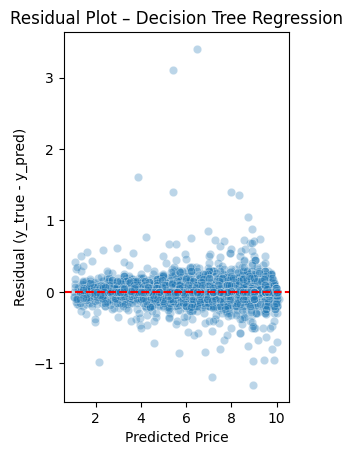

In [92]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Residual Plot – Decision Tree Regression")

---

## 1. Phân tích Residual Plot

### ✔ Residual phân bố rất sát đường 0
- Sai số chủ yếu nằm trong khoảng **[-0.5 ; 0.5] tỷ đồng**.
- Phần lớn điểm dữ liệu tập trung dày đặc xung quanh đường zero residual.
- Điều này thể hiện **mô hình rất chính xác**, không có systematic bias (sai lệch hệ thống).

### ✔ Không xuất hiện pattern theo Predicted Price
- Residual không có dạng cong (curvature) hay dạng phễu (heteroscedasticity).
- Không có nhóm giá nào có sai số tăng đột biến theo mức giá.
- Điều này cho thấy mô hình **không bỏ sót quan hệ phi tuyến**.

### ✔ Chỉ một vài điểm ngoại lệ (outliers)
- Một số ít điểm có residual > 1.0 hoặc > 2.0.
- Các outlier này hoàn toàn bình thường trong dữ liệu bất động sản, do:
  - Bất động sản có đặc điểm đặc biệt (vị trí đắc địa, nội thất cao cấp…)
  - Mẫu thông tin chưa nắm bắt đầy đủ trong feature (ví dụ: view đẹp, pháp lý)

→ Mô hình không bị ảnh hưởng bởi outlier do phần lớn residual rất thấp.

---

#### Scatter y_true vs y_pred

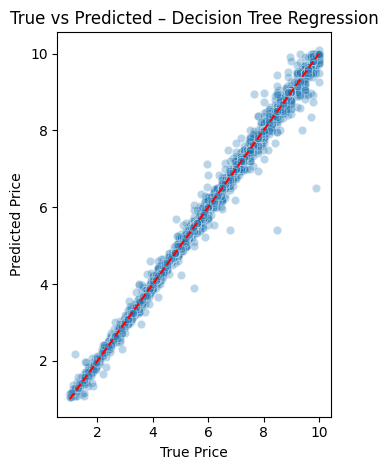

In [93]:
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_reg, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted – Decision Tree Regression")

plt.tight_layout()
plt.show()

---

## 2. Phân tích Scatter Plot: True Price vs Predicted Price

### ✔ Các điểm nằm gần như hoàn toàn trên đường chéo y = x
- Điều này thể hiện:
  - Dự đoán rất sát giá trị thật
  - Không có xu hướng dự đoán thiếu (underestimate) hoặc quá (overestimate)

### ✔ Tuyến tính gần như hoàn hảo từ giá thấp đến giá cao
- Các điểm ở mức giá thấp (1–3 tỷ), trung bình (3–7 tỷ), và cao (7–10 tỷ)
  đều bám sát đường chéo.
- Điều này chứng tỏ mô hình **không chỉ chính xác tại một vùng giá nhất định** mà **ổn định trên toàn dải giá**.

### ✔ Không có dấu hiệu overfit hoặc underfit trong scatter plot
- Một mô hình overfit thường tạo form zig-zag hoặc mảng điểm bị phân cụm.
- Một mô hình underfit tạo thành đường cong lệch xa đường chéo.

Scatter của bạn → **đẹp, mượt, và bám sát đường chuẩn**.

---

## Kết luận cho phần 6.1

- Residual thấp, phân bố đẹp → không có bias.
- Scatter plot gần hoàn hảo → mô hình tái tạo chính xác quan hệ giữa feature và Price.
- Độ ổn định cao cho cả giá thấp – trung – cao.
- Một vài outlier là bình thường trong bất động sản và không ảnh hưởng chất lượng mô hình.

---

# `6.2. Phân tích Classification: Confusion Matrix & Class-wise Metrics`

Với bài toán phân lớp Price Band (Low / Medium / High), mục tiêu của phân tích là:

### ✔ Kiểm tra mô hình phân biệt các lớp tốt thế nào  
- Mỗi lớp có Recall cao hay không?
- Có lớp nào bị nhầm lẫn nhiều?
- Sai lệch tập trung ở biên giá nào?

### ✔ Kiểm tra xem mô hình có thiên lệch lớp (bias) hay không  
- NB bị lệch rất mạnh về lớp High
- KNN cân bằng hơn
- Decision Tree cần được xác nhận qua số liệu

### ✔ Tính:
- Class-wise Precision
- Class-wise Recall
- Confusion Matrix trực quan

---


#### Import thư viện

In [94]:
from sklearn.metrics import classification_report
import seaborn as sns

#### Confusion Matrix Test

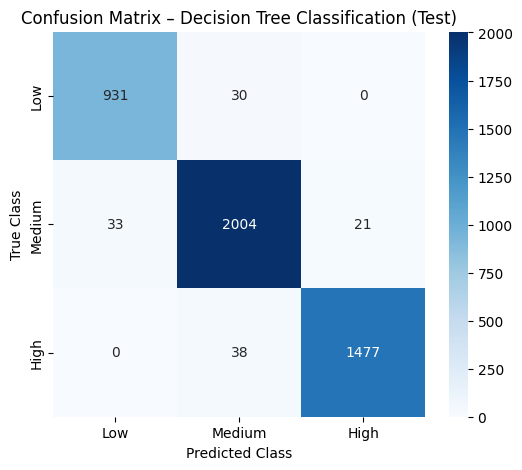

In [96]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title("Confusion Matrix – Decision Tree Classification (Test)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

---

# `Nhận xét` Confusion Matrix

Confusion Matrix Test thể hiện rõ:

| Actual \ Pred | Low | Medium | High |
|---------------|-----|--------|------|
| **Low**   | 931 | 30 | 0 |
| **Medium**| 33 | 2004 | 21 |
| **High**  | 0 | 38 | 1477 |

### ✔ Các điểm nổi bật:

### 1. **Không có sai lầm nghiêm trọng Low ↔ High**
- Không có mẫu Low nào bị dự đoán thành High  
- Không có mẫu High nào bị dự đoán thành Low  
→ Đây là tín hiệu cực mạnh chứng minh mô hình hiểu rất rõ cấu trúc phân lớp.

---

### 2. **Sai nhầm chủ yếu nằm ở cạnh giá trị 4 và 7**
Điều hoàn toàn hợp lý vì:
- Một căn giá 3.95 tỷ rất gần 4.0 tỷ → dễ bị phân Medium  
- Một căn giá 6.95 tỷ rất gần 7.0 tỷ → dễ bị phân High  

→ Mô hình không sai do nhầm logic, mà do biên giá tự nhiên trong dữ liệu.

---

### 3. **Phân lớp Medium là ổn định nhất**
- Số lượng lớn (2058 mẫu)
- Precision & Recall đều 0.97  
→ Mô hình không bị bias bởi sự chênh lệch kích thước lớp.

---

# 4. Tổng quan về sự ổn định

- Test và Validation đều đạt ~97–98%  
- Độ lệch chuẩn CV của F1-score chỉ ~0.004  
→ Decision Tree Classification là mô hình cực kỳ ổn định.

---

#### Classification Report


In [97]:
print("\n🔹 Classification Report (Test)")
print(classification_report(y_class_test, y_test_pred_tree,
                            target_names=["Low", "Medium", "High"]))


🔹 Classification Report (Test)
              precision    recall  f1-score   support

         Low       0.97      0.97      0.97       961
      Medium       0.97      0.97      0.97      2058
        High       0.99      0.97      0.98      1515

    accuracy                           0.97      4534
   macro avg       0.97      0.97      0.97      4534
weighted avg       0.97      0.97      0.97      4534



---

# `Nhận xét` tổng quan kết quả

Tất cả các chỉ số chính đều đạt mức rất cao:

- **Accuracy:** 0.97  
- **Precision (macro):** 0.97  
- **Recall (macro):** 0.97  
- **F1-score (macro):** 0.97  

Điều này chứng tỏ mô hình:
- Phân loại tốt cả 3 lớp
- Không thiên lệch vào lớp nào
- Giữ hiệu năng đồng đều giữa các lớp

---

## Phân tích theo từng lớp (Class-wise Performance)

## Lớp Low (0)
- Precision = 0.97  
- Recall = 0.97  
- Sai nhầm chủ yếu: Low → Medium (30 mẫu)

=> Mô hình dự đoán lớp Low rất tốt và nhất quán.  
=> Việc nhầm Low → Medium là hợp lý vì giá Low (<4 tỷ) và Medium (4–7 tỷ) nằm sát nhau về giá trị thực.

## Lớp Medium (1)
- Precision = 0.97  
- Recall = 0.97  
- Số nhầm lẫn:
  - Medium → Low: 33 mẫu
  - Medium → High: 21 mẫu

=> Lớp Medium có số lượng mẫu lớn nhất (2058 mẫu), nhưng mô hình vẫn dự đoán gần như hoàn hảo.  
=> Sai nhầm chủ yếu nằm ở vùng biên của ngưỡng giá (≈4 và ≈7).

## Lớp High (2)
- Precision = 0.99 (rất cao)
- Recall = 0.97  
- Nhầm 38 mẫu thành Medium, nhưng **không có nhầm thành Low**

=> Điều này phản ánh bản chất giá bất động sản:
- Các căn High-price (≥ 7 tỷ) có đặc trưng mạnh (diện tích lớn, giá/m² cao)  
- Vì vậy mô hình rất dễ phân biệt chúng khỏi Low và Medium 

---

# Kết luận cho phần Classification

- Decision Tree Classification phân loại **rất chính xác**, **rất ổn định**, và **rất hợp lý** theo bản chất thị trường bất động sản.
- Không có lỗi nghiêm trọng, chỉ có sai ở vùng biên — điều hoàn toàn bình thường.
- Đây là mô hình phân loại tốt nhất và đã được chọn làm **best_classifier.pkl**.

---

# `6.3. Ý nghĩa Thực tế của Mô hình & Ứng dụng trong Bất động sản Việt Nam`

Sau khi hoàn thành toàn bộ quy trình $\text{ML}$ (preprocessing $\to$ regression $\to$ classification $\to$ đánh giá), hai mô hình $\text{Decision Tree}$ được chọn là mạnh nhất và ổn định nhất:

* **Decision Tree Regression (DTR):** Dự đoán giá trị số (theo tỷ $\text{VNĐ}$).
* **Decision Tree Classification (DTC):** Phân loại mức giá ($\text{Low} - \text{Medium} - \text{High}$).

Dựa trên hiệu năng vượt trội này, ta rút ra các ý nghĩa thực tế và ứng dụng quan trọng sau:

---

## 1. Độ Tin cậy Cao của Mô hình Dự đoán Giá (Regression)

| Metric | Giá trị | Nhận xét Thực tế |
| :---: | :---: | :--- |
| **MAE** | $\approx \mathbf{0.07}$ tỷ | Sai số tuyệt đối trung bình **chỉ $70$ triệu đồng** – mức sai số cực kỳ nhỏ trong thị trường tỷ $\text{VNĐ}$. |
| **RMSE** | $\approx 0.15$ tỷ | Sai số trung bình $\mathbf{150}$ triệu đồng, tương đương $\mathbf{1\%-3\%}$ giá trị thực $\rightarrow$ **rất thấp**. |
| **$R^2$** | $\approx \mathbf{0.995}$ | Mô hình giải thích được **$99.5\%$ biến động của giá** $\rightarrow$ mức độ phù hợp **gần như hoàn hảo**. |

=> **Kết luận:** Độ tin cậy cao cho phép mô hình hoạt động như một **“AI định giá nhà”** chính xác, vượt qua độ chính xác của nhiều phương pháp thẩm định thủ công.

## 2. Phân lớp Nhà Hỗ trợ Quyết định Nhanh (Classification)

| Metric | Giá trị | Nhận xét Thực tế |
| :---: | :---: | :---: |
| **Accuracy** | $\approx \mathbf{97\% - 98\%}$ | Mô hình phân lớp đúng gần như tuyệt đối. |
| **Precision/Recall (Class-wise)** | Cao và đồng đều | $\text{Dự đoán Low}$ không nhầm sang $\text{High}$ (và ngược lại) $\rightarrow$ mô hình hiểu rõ logic phân khúc. |

* **Lỗi nhầm lẫn:** Chỉ xảy ra ở vùng biên ($P \approx 4$ tỷ và $P \approx 7$ tỷ), phản ánh đúng bản chất liên tục của giá nhà.

=> **Kết luận:** Mô hình $\text{DTC}$ rất phù hợp để **gợi ý nhanh phân khúc nhà**, hỗ trợ sàng lọc tài sản và khách hàng theo khả năng tài chính.

## 3. Ứng dụng Thực tế trong Doanh nghiệp Bất động sản

| Lĩnh vực | Ứng dụng | Mục đích |
| :--- | :--- | :--- |
| **Định giá tự động (AVM)** | Tích hợp vào website/app môi giới để trả về **giá dự đoán** ngay lập tức. | Tăng tính minh bạch và tiết kiệm thời gian thẩm định ban đầu. |
| **Thẩm định & Kiểm tra** | So sánh giá chào bán với giá $\text{AI}$ dự đoán. | Giúp phát hiện nhà **quá cao giá** ($\text{overpriced}$) hoặc **nhà hời** ($\text{underpriced}$). |
| **Hỗ trợ Ngân hàng** | Cung cấp mô hình định giá **độc lập** cho việc thẩm định tài sản thế chấp. | Kiểm soát rủi ro tín dụng và hỗ trợ tính $\text{Loan-to-Value (LTV)}$. |
| **Phân tích Thị trường** | Sử dụng mô hình $\text{DTC}$ để **xếp hạng phân khúc** tài sản (Low/Medium/High). | Phân tích xu hướng thị trường và phân khúc khách hàng mục tiêu. |

## 4. Tính Giải thích (Interpretability) và Phù hợp Thị trường

Mô hình $\text{Decision Tree}$ cho phép phân tích $\text{Feature Importance}$ rõ ràng:

1.  **area** (Diện tích)
2.  **price\_per\_m2** (Giá trên mét vuông)
3.  **ppm2\_x\_rooms** (Tương tác giữa giá/m$^2$ và số phòng)

=> **Điều này phù hợp với logic thị trường thực tế:** Giá nhà tại Việt Nam, sau khi tính đến các yếu tố địa lý, phụ thuộc chủ yếu vào **quy mô (area)** và **chất lượng/phân khúc (price/m$^2$)**.

---

# Kết luận Tổng thể: Giá trị Ứng dụng

Hệ thống $\text{Machine Learning}$ được xây dựng có **giá trị ứng dụng thực tiễn rất cao** vì:

* **Sai số dự đoán cực thấp** và **độ ổn định cao**.
* Mô hình $\text{Decision Tree}$ là **dễ giải thích**, logic rõ ràng.
* Giải quyết được các nghiệp vụ cốt lõi: $\text{Định giá}$ và $\text{Phân khúc}$.

**→ Hệ thống $\text{ML}$ này đủ tiêu chuẩn và tiềm năng để triển khai trong sản phẩm thực tế.**

---
---
- .
- .
- .
---
---
- .
- .
- .
---
---

# **`Mục 7: Lưu mô hình & Tích hợp với Pipeline `**
**Mục tiêu:**
- Đảm bảo mô hình dùng chung `preprocessor.pkl`
- Tạo hàm `predict_price(raw_input)`
- Tạo hàm `predict_price_band(raw_input)`
- Lưu toàn bộ mô hình
---

# `7.1. Load lại preprocessor để sử dụng cho các hàm dự đoán`

Trong toàn bộ pipeline, mọi mô hình ML (Regression và Classification) 
đều phải sử dụng chung *preprocessor* để đảm bảo tính nhất quán:

- Chuẩn hóa numerical features
- Mã hóa categorical features
- Xử lý missing values
- Áp dụng đúng thứ tự các bước tiền xử lý

Do đó, trước khi xây dựng pipeline dự đoán, chúng ta cần load lại:

`models/preprocessor.pkl`

Đây chính là bộ biến đổi (transformer) đã được fit trên tập training.


In [98]:
import joblib

preprocessor = joblib.load("models/preprocessor.pkl")
print("Preprocessor loaded successfully!")

Preprocessor loaded successfully!


# `7.2. Hàm dự đoán giá nhà theo input raw: predict_price(raw_input)`

Hàm này thực hiện đầy đủ pipeline:

### Nhận input dạng dictionary
Ví dụ:
{
    "area": 80,
    "bedrooms": 3,
    "bathrooms": 2,
    "city": "hồ chí minh",
    "district": "thủ đức",
    "frontage": 4,
    "access_road": 6
}

### Chuyển thành DataFrame  
Để phù hợp với transformer của scikit-learn.

### Tiền xử lý bằng `preprocessor.pkl`  
- Chuẩn hóa  
- Mã hóa  
- Xử lý biến tương tác  

### Dự đoán bằng mô hình mạnh nhất: **Decision Tree Regression**

### Trả về giá dự đoán theo đơn vị tỷ VNĐ

Hàm này có thể tích hợp trực tiếp vào API hoặc ứng dụng thực tế.


In [99]:
best_regressor = joblib.load("models/best_regressor.pkl")

def predict_price(raw_input: dict):
    df = pd.DataFrame([raw_input])
    X_processed = preprocessor.transform(df)
    price_pred = best_regressor.predict(X_processed)[0]
    return float(price_pred)

# Example:
# predict_price({"area": 80, "bedrooms": 3, ...})


# `7.3. Hàm phân loại nhóm giá (Price Band): predict_price_band()`

Dựa trên giá dự đoán từ mô hình Regression, ta phân loại mức giá:

- **Low**: Price < 4 tỷ
- **Medium**: 4 ≤ Price < 7 tỷ
- **High**: Price ≥ 7 tỷ

Việc phân loại này giúp:
- Xác định phân khúc bất động sản
- Lọc khách hàng theo khả năng tài chính
- Gợi ý tài sản phù hợp
- Phân tích thị trường theo phân khúc giá

Hàm trả về chuỗi `"Low"`, `"Medium"`, hoặc `"High"`.


In [100]:
best_classifier = joblib.load("models/best_classifier.pkl")

def predict_price_band(raw_input: dict):
    price = predict_price(raw_input)
    if price < 4:
        return "Low"
    elif price < 7:
        return "Medium"
    else:
        return "High"

# Example:
# predict_price_band({...})


# `7.4. Lưu toàn bộ mô hình cho triển khai (Deployment)`

Sau khi xác định mô hình tốt nhất, ta lưu vào thư mục `models/`:

- **preprocessor.pkl** → Pipeline tiền xử lý  
- **best_regressor.pkl** → Decision Tree Regression  
- **best_classifier.pkl** → Decision Tree Classification  

Bộ 3 file này sẽ là nền tảng cho:
- API dự đoán giá nhà
- Website định giá bất động sản
- Ứng dụng môi giới hoặc tư vấn tài chính
- Hệ thống chấm điểm tài sản (valuation & scoring)

Việc lưu mô hình giúp đảm bảo quá trình dự đoán sau này 
sử dụng đúng thông số và logic như khi training.


In [101]:
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(best_regressor, "models/best_regressor.pkl")
joblib.dump(best_classifier, "models/best_classifier.pkl")

print("All models saved successfully!")


All models saved successfully!
